# 1.Package Import

In [1]:
from bmovie_code import gen_table1_subj_info
from pynwb import NWBHDF5IO
from pathlib import Path
import numpy as np
import pandas as pd

from new_code import data_summary, load_data_into_pds, load_data_into_dict, slicer, label, feature, decompose, fusion, new_fusion

import pickle
from scipy.signal import detrend

In [2]:
%load_ext autoreload
%autoreload 2

# 2. Global file location (need to specify your own path)

In [3]:
NWB_DIR="/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files"
BIDS_DIR="/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/bids_files"

In [4]:
gen_table1_subj_info.main(
    nwb_input_dir=NWB_DIR,
    bids_datadir=BIDS_DIR
)

# 3. Load labels and data

In [5]:
# labels
with open("../assets/annotations/short_faceannots.pkl", "rb") as f:
    face_annots = pickle.load(f)

type(face_annots)
# print(list(face_annots.items())[:10])

path = "../assets/annotations/scenecut_info.csv"
scenecut_info = pd.read_csv(path)

print(scenecut_info.head())

   scene_id  shot_start_fr  shot_start_t  shot_dur_t  location cut_type  \
0       1.0            1.0          0.00        4.72  backyard      cut   
1       1.0          119.0          4.72       10.28  backyard      cut   
2       1.0          376.0         15.00        1.72  backyard      cut   
3       1.0          419.0         16.72        2.36  backyard      cut   
4       1.0          478.0         19.08        2.64  backyard      cut   

   cut_dur_t  cut_dur_fr  
0        0.0           0  
1        0.0           0  
2        0.0           0  
3        0.0           0  
4        0.0           0  


In [6]:
df_face_note = label.build_face_feature_df(face_annots, target_id="Jacky")
print(df_face_note.tail())

        frame_key  frame_idx  movie_time  n_faces  total_face_area  \
9373  frame_11898      11898      475.92        2      35470.00073   
9374  frame_11899      11899      475.96        2      35470.00073   
9375  frame_11900      11900      476.00        2      35470.00073   
9376  frame_11901      11901      476.04        2      35470.00073   
9377  frame_11902      11902      476.08        2      35470.00073   

      max_face_area  Jacky_present  any_front_face dominant_emotion  \
9373   24058.686485              0               1        surprised   
9374   24058.686485              0               1        surprised   
9375   24058.686485              0               1        surprised   
9376   24058.686485              0               1        surprised   
9377   24058.686485              0               1        surprised   

      emo_afraid  emo_angry  emo_happy  emo_neutral  emo_surprised  
9373       False      False      False        False           True  
9374       Fal

## 3.1 Label Check

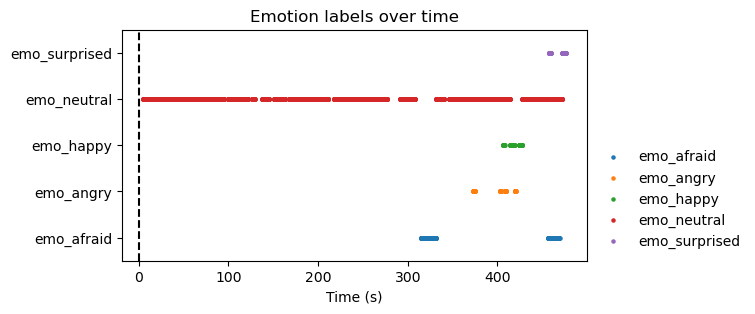

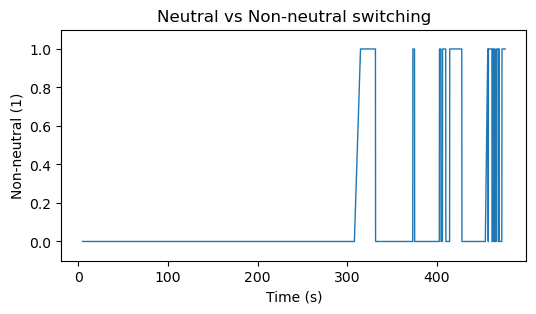

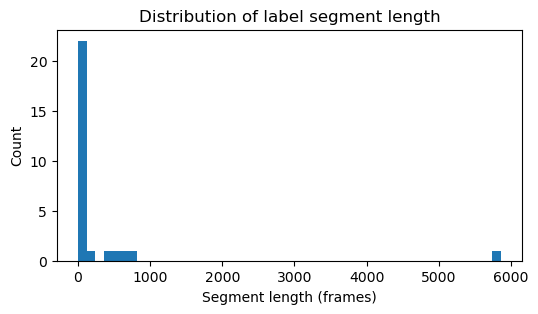

median: 47.0
short (<5 frames): 0.0


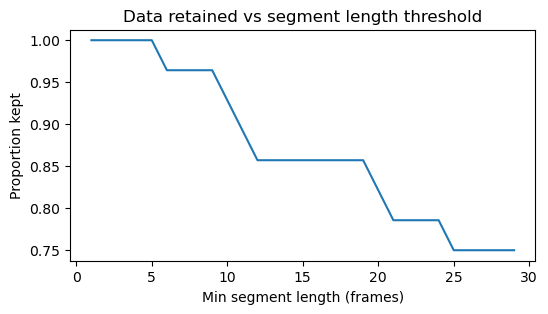

In [7]:
import matplotlib.pyplot as plt

emo_cols = [
    "emo_afraid",
    "emo_angry",
    "emo_happy",
    "emo_neutral",
    "emo_surprised"
]

t = df_face_note["movie_time"].values

# ===================================
# face emotion label check
# ===================================
plt.figure(figsize=(6, 3))

for i, col in enumerate(emo_cols):
    y = df_face_note[col].astype(int) * (i + 1)
    plt.scatter(t, y, s=5, label=col)

plt.axvline(0, color="black", linestyle="--")
plt.yticks(range(1, len(emo_cols)+1), emo_cols)
plt.ylim(0.5, len(emo_cols)+0.5)
plt.xlabel("Time (s)")
plt.title("Emotion labels over time")
plt.legend(bbox_to_anchor=(1.0,0), loc="lower left", frameon=False)
plt.show()

# ===================================
# face emotion switching
# ===================================
is_non_neutral = ~df_face_note["emo_neutral"]

plt.figure(figsize=(6, 3))
plt.plot(t, is_non_neutral.astype(int), linewidth=1)

plt.xlabel("Time (s)")
plt.ylabel("Non-neutral (1)")
plt.title("Neutral vs Non-neutral switching")
plt.ylim(-0.1, 1.1)
plt.show()

# ===================================
# distribution check
# ===================================
labels = df_face_note["dominant_emotion"].values

segments = []
start = 0

for i in range(1, len(labels)):
    if labels[i] != labels[i-1]:
        segments.append((labels[i-1], start, i-1))
        start = i

segments.append((labels[-1], start, len(labels)-1))

lengths = [end - start + 1 for (_, start, end) in segments]

plt.figure(figsize=(6, 3))
plt.hist(lengths, bins=50)
plt.xlabel("Segment length (frames)")
plt.ylabel("Count")
plt.title("Distribution of label segment length")
plt.show()

print("median:", np.median(lengths))
print("short (<5 frames):", np.mean(np.array(lengths) < 5))

# ===================================
# screen check
# ===================================

lengths = np.array(lengths)

thresholds = np.arange(1, 30)
proportion = [(lengths >= th).mean() for th in thresholds]

plt.figure(figsize=(6, 3))
plt.plot(thresholds, proportion)
plt.xlabel("Min segment length (frames)")
plt.ylabel("Proportion kept")
plt.title("Data retained vs segment length threshold")
plt.show()

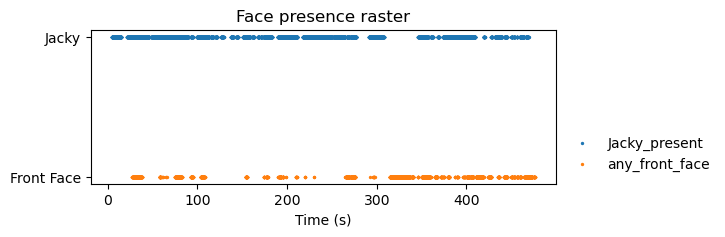

In [8]:
import matplotlib.pyplot as plt

t = df_face_note["movie_time"].values

jacky = df_face_note["Jacky_present"].astype(int).values
front = df_face_note["any_front_face"].astype(int).values

plt.figure(figsize=(6, 2))

plt.scatter(t[jacky == 1], [1]*np.sum(jacky==1), s=2, label="Jacky_present")
plt.scatter(t[front == 1], [0]*np.sum(front==1), s=2, label="any_front_face")

plt.yticks([0, 1], ["Front Face", "Jacky"])
plt.xlabel("Time (s)")
plt.title("Face presence raster")
plt.legend(bbox_to_anchor=(1.0,0), loc="lower left", frameon=False)
plt.show()

In [9]:
nwb_path = load_data_into_pds.find_nwb_file_for_subject(NWB_DIR, "CS41")
print("Using:", nwb_path)

io = NWBHDF5IO(str(nwb_path), "r", load_namespaces=True)
nwb = io.read()

print("\n=== acquisition keys ===")
print(list(nwb.acquisition.keys()))

print("\n=== processing modules ===")
print(list(nwb.processing.keys()))

for mod_name, mod in nwb.processing.items():
    print(f"\n--- processing[{mod_name}] keys ---")
    try:
        print(list(mod.data_interfaces.keys()))
    except Exception as e:
        print("cannot list data_interfaces:", e)

print("\n=== stimulus keys ===")
print(list(getattr(nwb, "stimulus", {}).keys()))

print("\n=== intervals ===")
print(list(getattr(nwb, "intervals", {}).keys()))

io.close()

Using: /Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb

=== acquisition keys ===
['events_ttl', 'experiment_ids']

=== processing modules ===
['behavior', 'ecephys']

--- processing[behavior] keys ---
['Blink', 'EyeTracking', 'Fixation', 'PupilTracking', 'Saccade']

--- processing[ecephys] keys ---
['LFP_macro', 'LFP_micro']

=== stimulus keys ===
['movieframe_time']

=== intervals ===
['trials']


In [10]:
from pynwb import NWBHDF5IO
io = NWBHDF5IO("/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb", "r", load_namespaces=True)
nwb = io.read()

ece = nwb.processing["ecephys"]
print("LFP_macro electrical_series keys:", list(ece["LFP_macro"].electrical_series.keys()))
print("LFP_micro electrical_series keys:", list(ece["LFP_micro"].electrical_series.keys()))

beh = nwb.processing["behavior"]
print("EyeTracking spatial_series keys:", list(beh["EyeTracking"].spatial_series.keys()))
print("PupilTracking time_series keys:", list(beh["PupilTracking"].time_series.keys()))

io.close()

LFP_macro electrical_series keys: ['ElectricalSeries']
LFP_micro electrical_series keys: ['ElectricalSeries']
EyeTracking spatial_series keys: ['SpatialSeries']
PupilTracking time_series keys: ['TimeSeries']


In [11]:
sub_nums = [47]
# sub_nums = [41, 42, 43, 44, 47, 48, 49, 51, 53, 54, 55, 56, 57, 58, 60, 62]
    
filter_config = {
    "lfp_macro": [
        {"type": "bandstop", "low": 58, "high": 62, "order": 4},
        {"type": "bandstop", "low": 118, "high": 122, "order": 4},
        {"type": "bandpass", "low": 0.5, "high": 150, "order": 4},
    ],
    "lfp_micro": [
        {"type": "bandstop", "low": 58, "high": 62, "order": 4},
        {"type": "bandstop", "low": 118, "high": 122, "order": 4},
        {"type": "bandpass", "low": 0.5, "high": 150, "order": 4},
    ],
    "eye_gaze":  {"type": "lowpass",  "high": 20.0, "order": 4},
    "pupil":     {"type": "lowpass",  "high": 10.0, "order": 4},
}

data = load_data_into_dict.load_multimodal_subjects_movie_aligned(
    sub_nums=sub_nums,
    nwb_root=NWB_DIR,
    bids_root=BIDS_DIR,
    max_nwb_samples=2000000,
    b_filter_data=True,
    filter_config=filter_config,
    
    grid_source= "lfp_raw",   # {"movie_frame_time", "uniform", "lfp_raw"}
    grid_dt = None,         # used when grid_source == "uniform"
    uniform_grid_include_baseline = True,

    compute_firing_rate= True,
    firing_rate_bin_width= None,  # if None, infer from t_grid
    compute_lfp_bandpower= True,
    lfp_bandpower_on_raw= True,       # recommended
    bands= None,

    # optional fmri
    load_fmri= False,
    fmri_max_runs= None,
)

# print(data[47].keys())
# print(data[47]['meta'])
# print(data[47]["lfp_macro"].shape, data[47]["eye_gaze"].shape)
# # print("n_units:", data[47]["meta"]["n_units"], "firing_rate:", data[47]["firing_rate"].shape)
# print("band keys:", list(data[47]["lfp_bandpower"].keys()))
# # data[47]["lfp_macro"][:, :5]
# x = data[41]["lfp_macro"]
# t = data[41]["time_grid"]
# print(x.shape, len(t))

[sub 47] t_eye_raw range=(0.000, 749.190)
[sub 47] nwb_path=/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS47/sub-CS47_ses-P47CSR1_behavior+ecephys.nwb
[sub 47] fs_macro=1000.0, fs_micro=1000.0, fs_eye=499.9999999976126
[sub 47] t_macro_movie range=(-10.000, 749.446)
[sub 47] movieframe_time(frame) range=(0.000, 11970.000)
[sub 47] movieframe_time_sec range=(0.000, 478.800)
[sub 47] t_grid len=759447 source=lfp_raw


In [12]:
# eye_data = data[41]["eye_gaze"]
# print("movie_time shape:", data[41]["movieframe_time"].shape)
# print("eye_gaze shape:", eye_data.shape)
# print(eye_data[:5])

# 4. Face Encoding Model
## 4.1 Feature Engineering

In [13]:
norm_modality_dict = {
    "firing_rate": [True, "max"],
    "lfp_macro": [False, "zscore"],
    "lfp_micro": [False, "zscore"],
    "eye_gaze": [True, "min_max"],
    "pupil": [True, "max"],
}

all_window_data = feature.build_all_subject_window_datasets(
    out=data,
    df_face_note=df_face_note,
    window_size_sec=0.5,          # 500 ms
    stride_sec=0.25,               # 100 ms stride
    start_time=0.0,
    end_time=478.800,
    remove_baseline_windows=True,
    do_baseline_norm=True,
    norm_modality_dict=norm_modality_dict,
    baseline_mode="zscore",
    baseline_start=-10.0,
    baseline_end=0.0,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    use_only_valid_face_frames=True,
    valid_face_mode="front_or_face",
    require_all_modalities_nonempty=False,
    verbose=True,
)

all_window_data_filtered = {}

# filter valid window, face ratio, min_frame
for sub, sub_data in all_window_data.items():
    all_window_data_filtered[sub] = feature.filter_window_dataset(
        sub_data,
        valid_window_only=True,
        min_valid_face_ratio=0.25,
        min_face_frames=5,
        min_non_neutral=None,
        allowed_hard_labels=None,
        require_modalities_nonempty=["firing_rate"],
        verbose=True,
    )

concat_data = feature.concat_subject_window_data(
    all_window_data_filtered,
    subjects=None,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    add_subject_column=True,
    reset_index=True,
    verbose=True,
)

[build] subject 47
normalized modality 'lfp_macro' with baseline mode 'zscore' using 10000 baseline samples.
normalized modality 'lfp_micro' with baseline mode 'zscore' using 10000 baseline samples.
  -> n_windows = 1914, valid_windows = 1914
[filter_window_dataset] kept 1520 / 1914 windows
[concat] sub=47, n_windows=1520
[concat_subject_window_data] total windows = 1520


In [14]:
print(concat_data["window_df"].columns)

Index(['sub', 'window_start', 'window_end', 'n_timepoints', 'valid_window',
       'n_face_frames_total', 'emo_afraid', 'emo_angry', 'emo_happy',
       'emo_neutral', 'emo_surprised', 'p_non_neutral', 'hard_label',
       'valid_face_ratio', 'front_face_ratio', 'jacky_ratio', 'mean_n_faces'],
      dtype='str')


[firing_rate] [sub=47] split by: emo
[firing_rate] [sub=47] neutral windows: 1321
[firing_rate] [sub=47] nonneutral windows: 199
[firing_rate] [sub=47] shared explained variance ratio: [0.13845076 0.12593249 0.05663995 0.0551424  0.04089772]


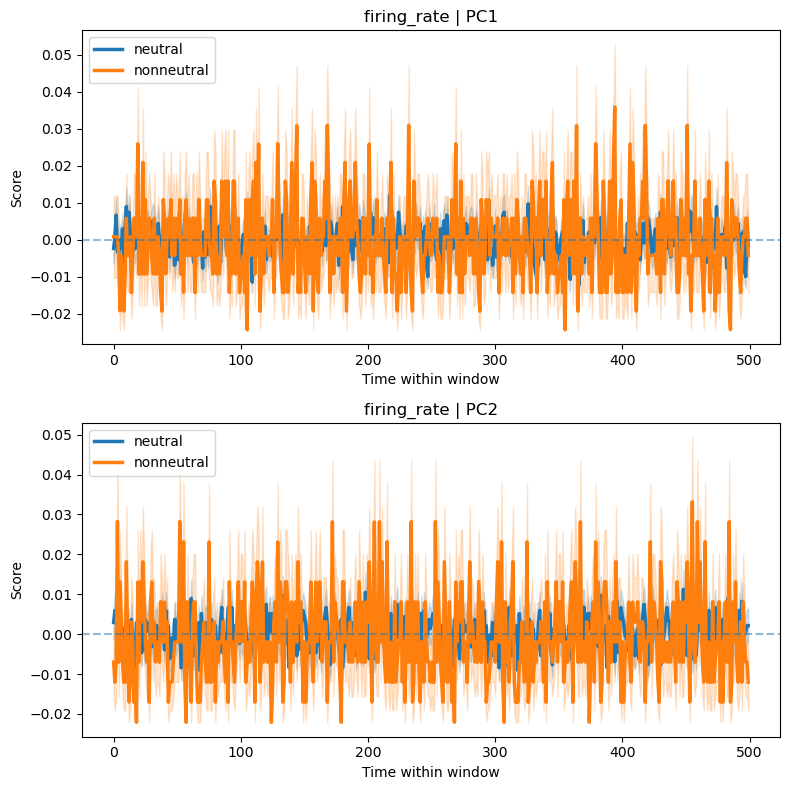

[lfp_macro] [sub=47] split by: emo
[lfp_macro] [sub=47] neutral windows: 1321
[lfp_macro] [sub=47] nonneutral windows: 199
[lfp_macro] [sub=47] shared explained variance ratio: [0.69349381 0.07433427 0.05874477 0.02333214 0.02177205]


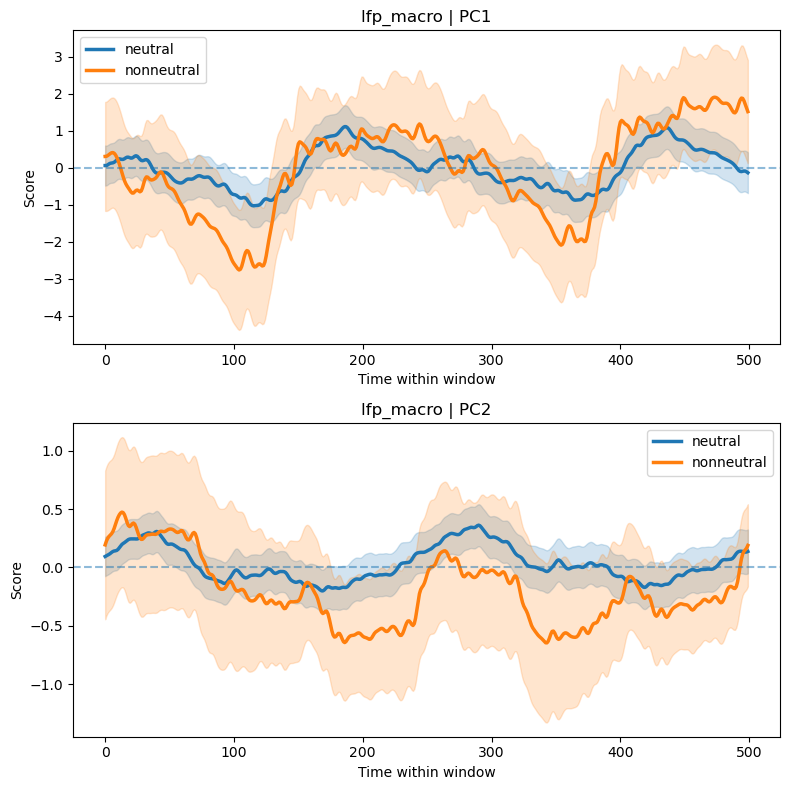

[lfp_micro] [sub=47] split by: emo
[lfp_micro] [sub=47] neutral windows: 1321
[lfp_micro] [sub=47] nonneutral windows: 199
[lfp_micro] [sub=47] shared explained variance ratio: [0.22617161 0.15984609 0.09812146 0.0609779  0.05548194]


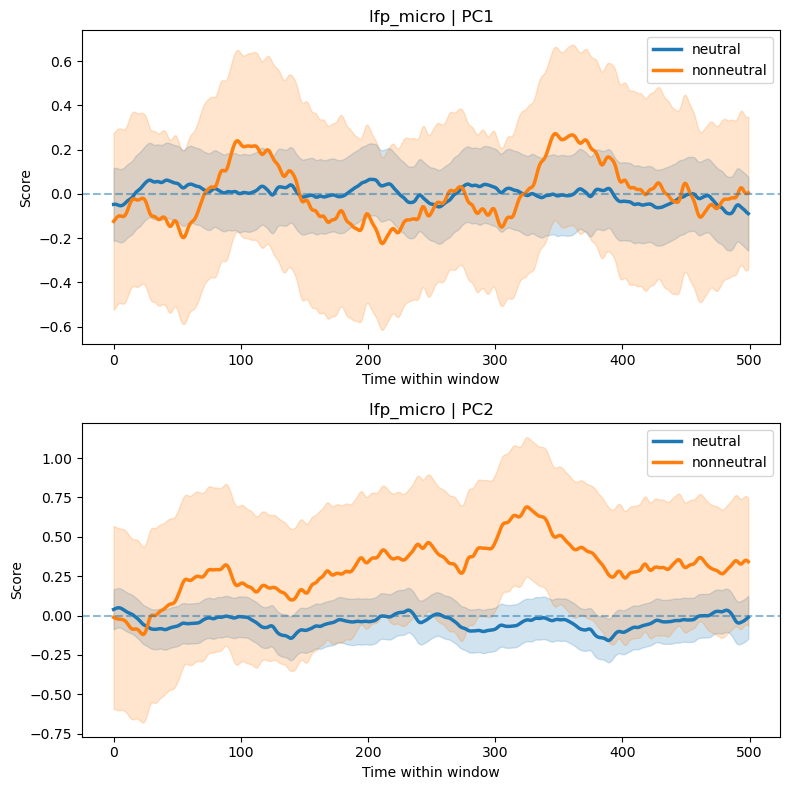

[eye_gaze] [sub=47] split by: emo
[eye_gaze] [sub=47] neutral windows: 1321
[eye_gaze] [sub=47] nonneutral windows: 199
[eye_gaze] [sub=47] shared explained variance ratio: [0.55022803 0.44977197]


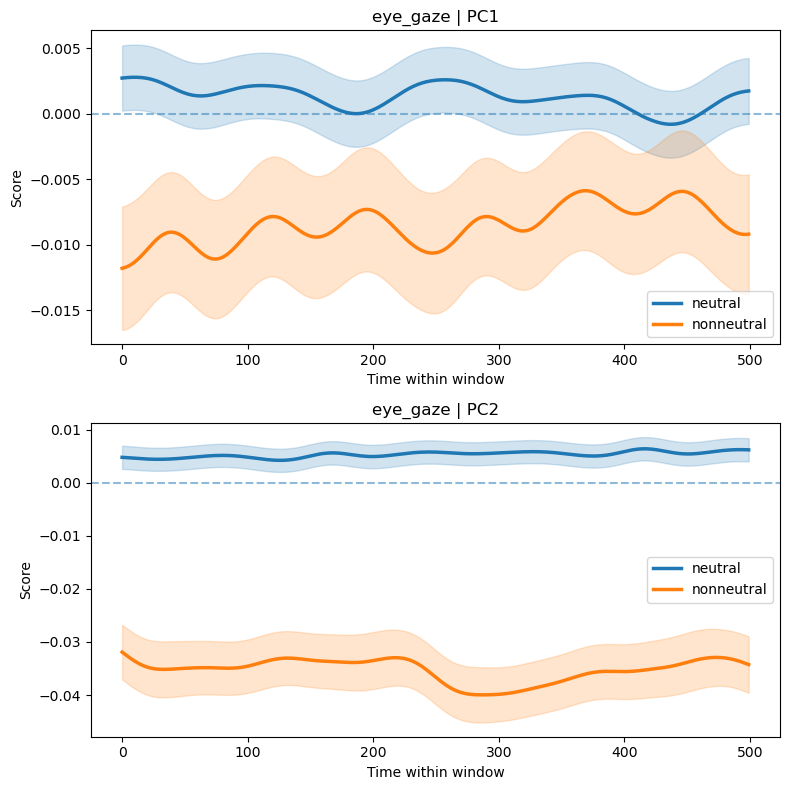

[pupil] [sub=47] split by: emo
[pupil] [sub=47] neutral windows: 1321
[pupil] [sub=47] nonneutral windows: 199
[pupil] [sub=47] shared explained variance ratio: [1.]


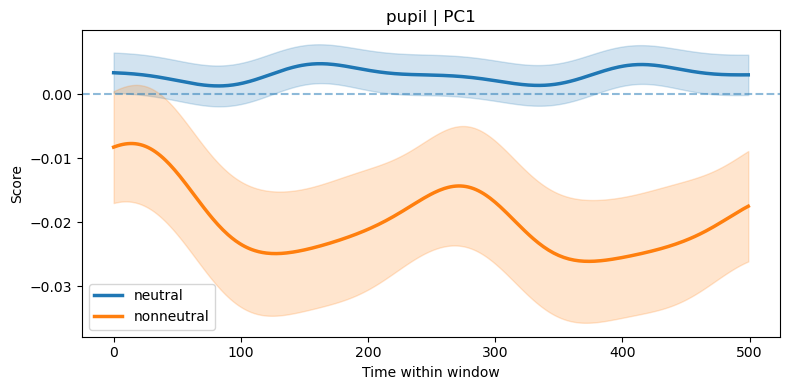

In [15]:
modality_keys = ["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"]
for mod in modality_keys:
    pca_res = decompose.run_grouped_trajectory_pca_on_concat_data(concat_data, modality=mod, n_components=5, split_by_sub=True)

    # decompose.plot_grouped_pca_across_sub(pca_res, pcx=1, pcy=2, alpha=0.3, equal_axis=True)
    # decompose.plot_grouped_pca_across_sub(pca_res, pcx=2, pcy=3, alpha=0.3, equal_axis=True)
    decompose.plot_pc_time_series_across_sub(pca_res, pcs=(1,2))

    # decompose.run_decoding_on_pca_res(pca_res, mode="time_mean")
    # decompose.run_decoding_on_pca_res(pca_res, mode="stats")
    # decompose.run_decoding_on_pca_res(pca_res, mode="channel_mean")

0.0 1.0
[firing_rate] [sub=47] split by: jacky
[firing_rate] [sub=47] no_jacky windows: 366
[firing_rate] [sub=47] jacky_present windows: 1154
[firing_rate] [sub=47] shared explained variance ratio: [0.13845076 0.12593249 0.05663995 0.0551424  0.04089772]


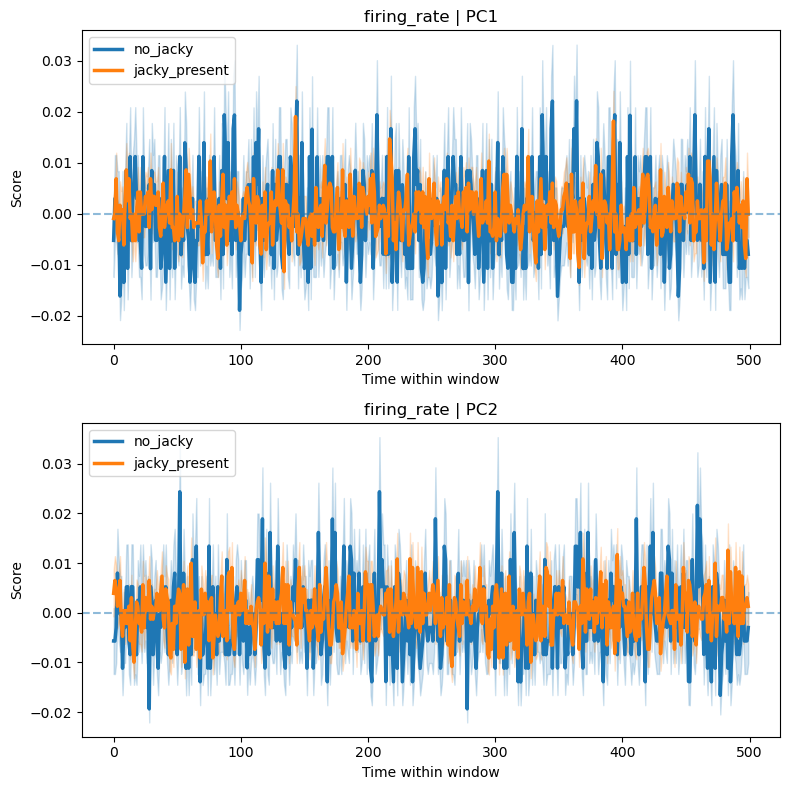

0.0 1.0
[lfp_macro] [sub=47] split by: jacky
[lfp_macro] [sub=47] no_jacky windows: 366
[lfp_macro] [sub=47] jacky_present windows: 1154
[lfp_macro] [sub=47] shared explained variance ratio: [0.69349381 0.07433427 0.05874477 0.02333214 0.02177205]


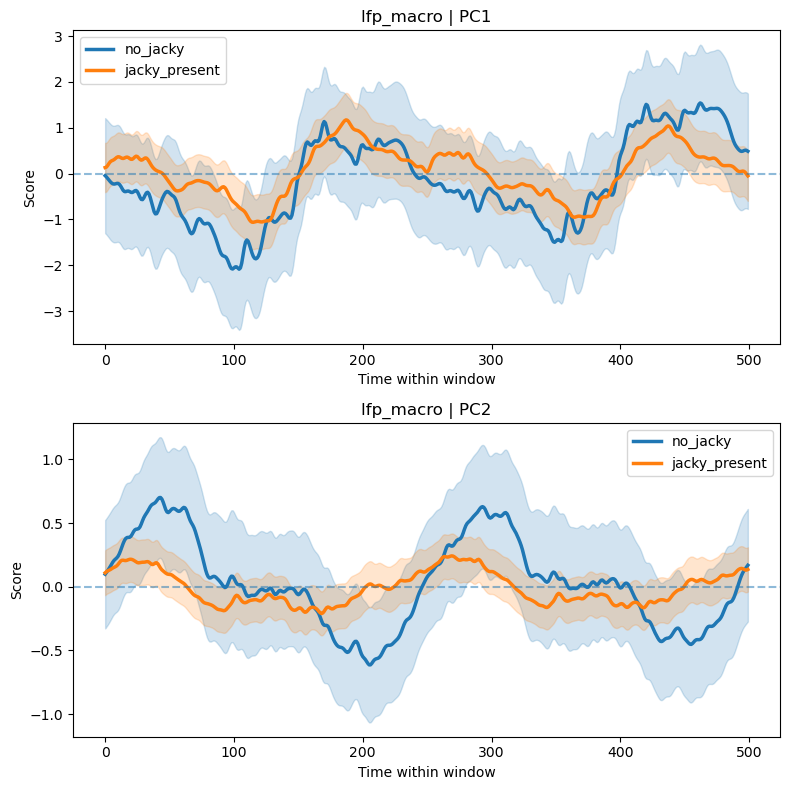

0.0 1.0
[lfp_micro] [sub=47] split by: jacky
[lfp_micro] [sub=47] no_jacky windows: 366
[lfp_micro] [sub=47] jacky_present windows: 1154
[lfp_micro] [sub=47] shared explained variance ratio: [0.22617161 0.15984609 0.09812146 0.0609779  0.05548194]


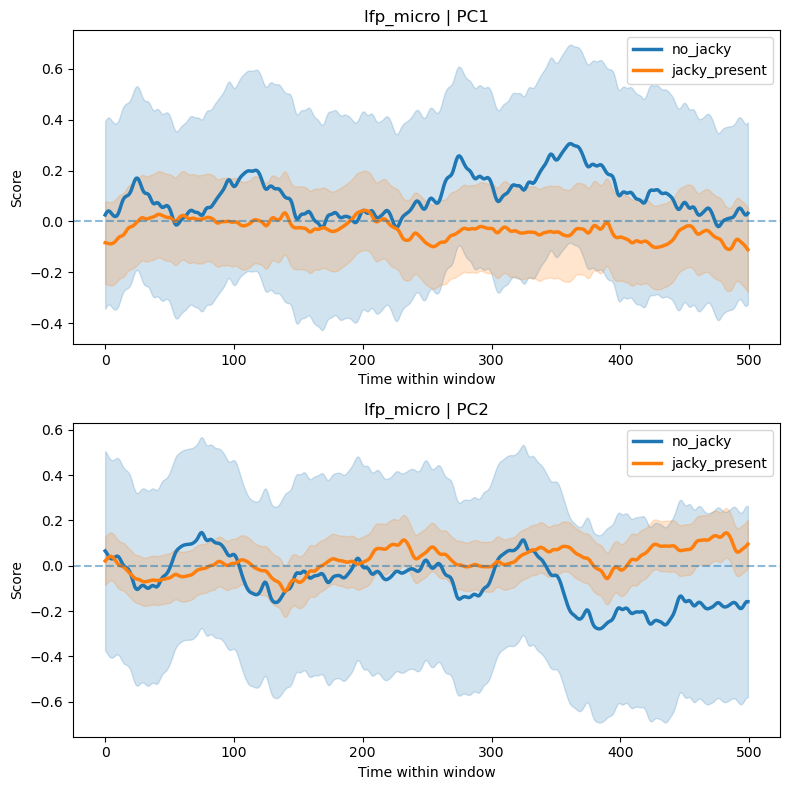

0.0 1.0
[eye_gaze] [sub=47] split by: jacky
[eye_gaze] [sub=47] no_jacky windows: 366
[eye_gaze] [sub=47] jacky_present windows: 1154
[eye_gaze] [sub=47] shared explained variance ratio: [0.55022803 0.44977197]


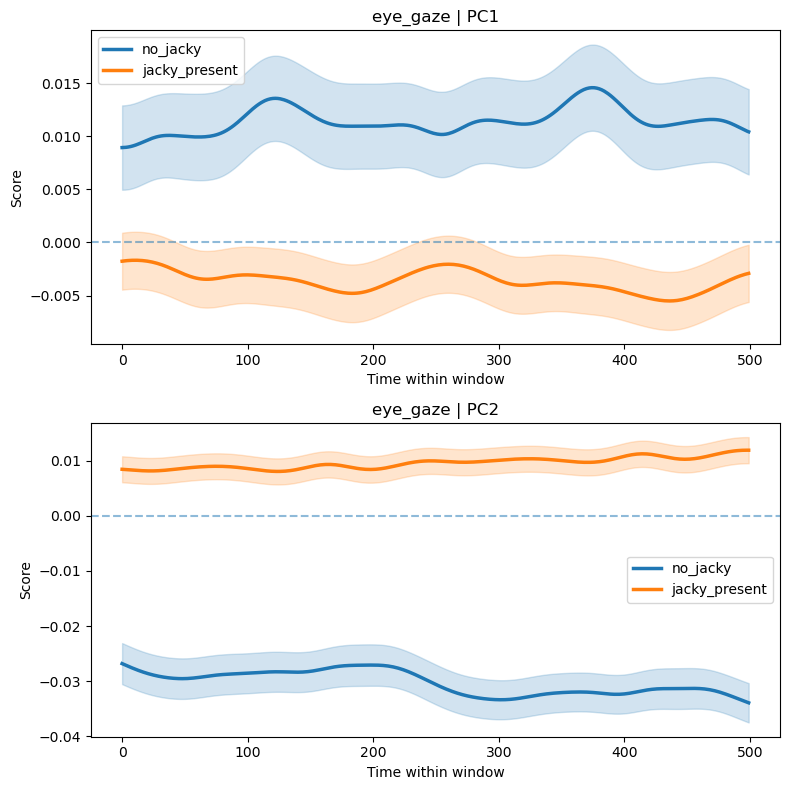

0.0 1.0
[pupil] [sub=47] split by: jacky
[pupil] [sub=47] no_jacky windows: 366
[pupil] [sub=47] jacky_present windows: 1154
[pupil] [sub=47] shared explained variance ratio: [1.]


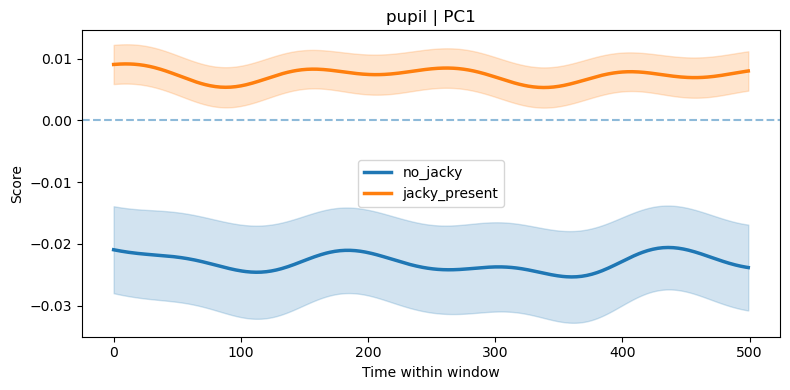

In [16]:
modality_keys = ["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"]
for mod in modality_keys:
    pca_res = decompose.run_grouped_trajectory_pca_on_concat_data(concat_data, spliter="jacky", eps=1.0, modality=mod, n_components=5, split_by_sub=True)

    # decompose.plot_grouped_pca_across_sub(pca_res, pcx=1, pcy=2, alpha=0.3, equal_axis=True)
    # decompose.plot_grouped_pca_across_sub(pca_res, pcx=2, pcy=3, alpha=0.3, equal_axis=True)
    decompose.plot_pc_time_series_across_sub(pca_res, pcs=(1,2))

    # decompose.run_decoding_on_pca_res(pca_res, mode="time_mean")
    # decompose.run_decoding_on_pca_res(pca_res, mode="stats")
    # decompose.run_decoding_on_pca_res(pca_res, mode="bandpower")
    # decompose.run_decoding_on_pca_res(pca_res, mode="channel_mean")

[firing_rate] [sub=47] split by: front_face
[firing_rate] [sub=47] no_front_face windows: 1111
[firing_rate] [sub=47] front_face_present windows: 409
[firing_rate] [sub=47] shared explained variance ratio: [0.13845076 0.12593249 0.05663995 0.0551424  0.04089772]


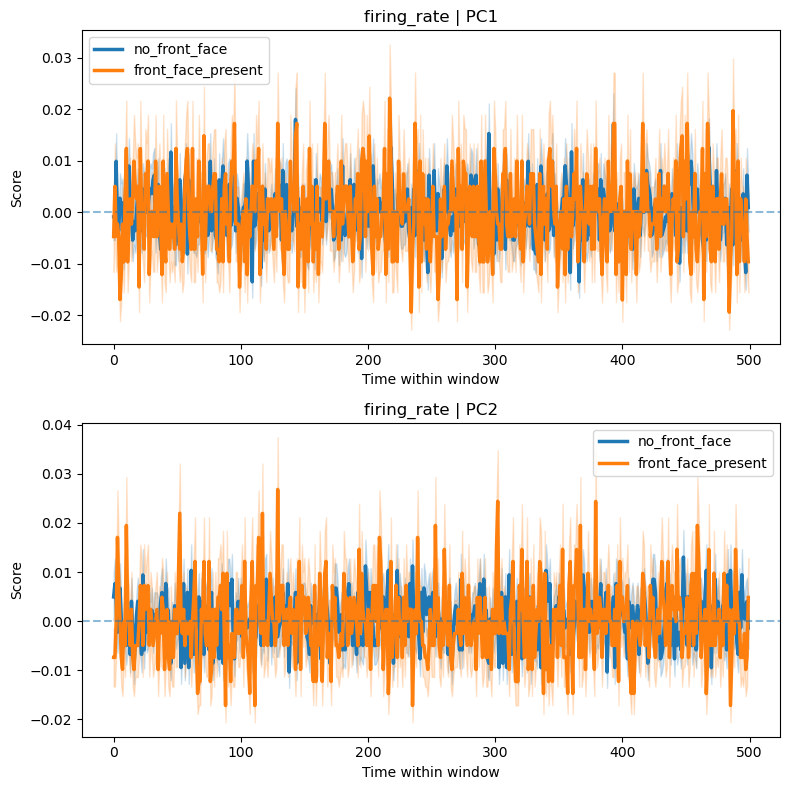

[lfp_macro] [sub=47] split by: front_face
[lfp_macro] [sub=47] no_front_face windows: 1111
[lfp_macro] [sub=47] front_face_present windows: 409
[lfp_macro] [sub=47] shared explained variance ratio: [0.69349381 0.07433427 0.05874477 0.02333214 0.02177205]


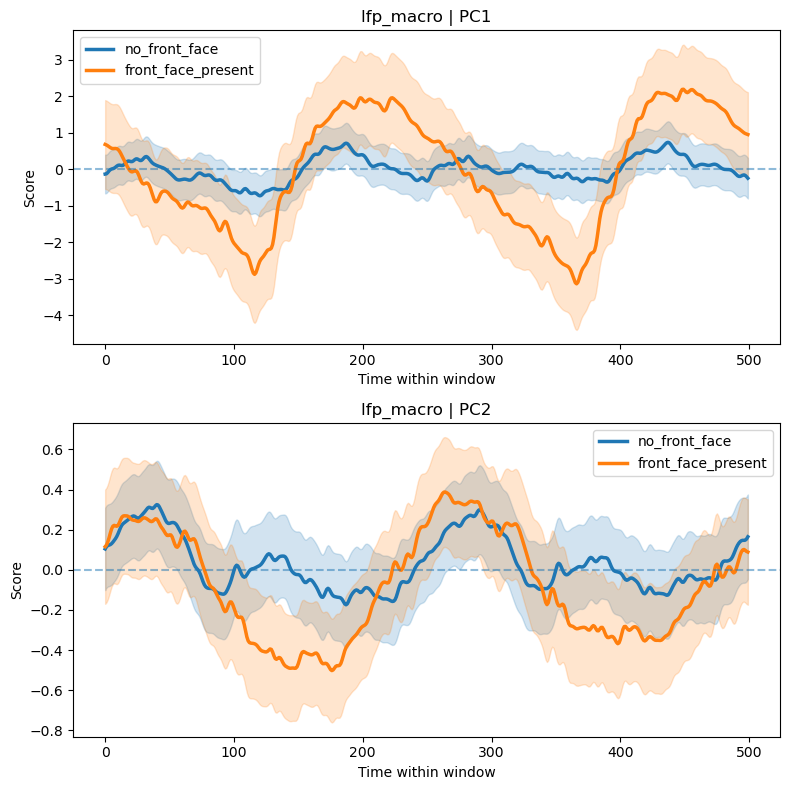

[lfp_micro] [sub=47] split by: front_face
[lfp_micro] [sub=47] no_front_face windows: 1111
[lfp_micro] [sub=47] front_face_present windows: 409
[lfp_micro] [sub=47] shared explained variance ratio: [0.22617161 0.15984609 0.09812146 0.0609779  0.05548194]


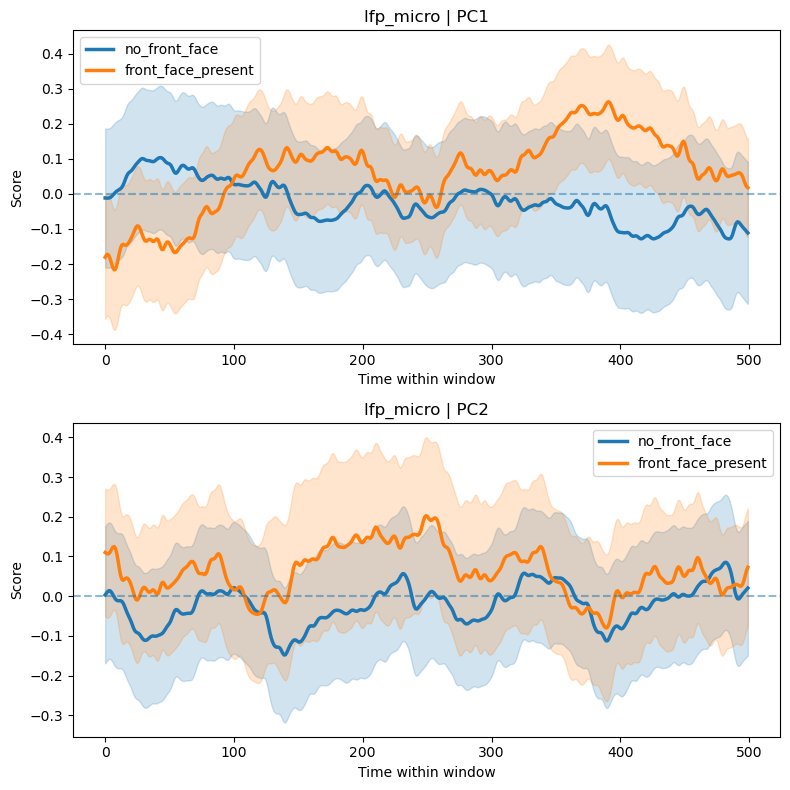

[eye_gaze] [sub=47] split by: front_face
[eye_gaze] [sub=47] no_front_face windows: 1111
[eye_gaze] [sub=47] front_face_present windows: 409
[eye_gaze] [sub=47] shared explained variance ratio: [0.55022803 0.44977197]


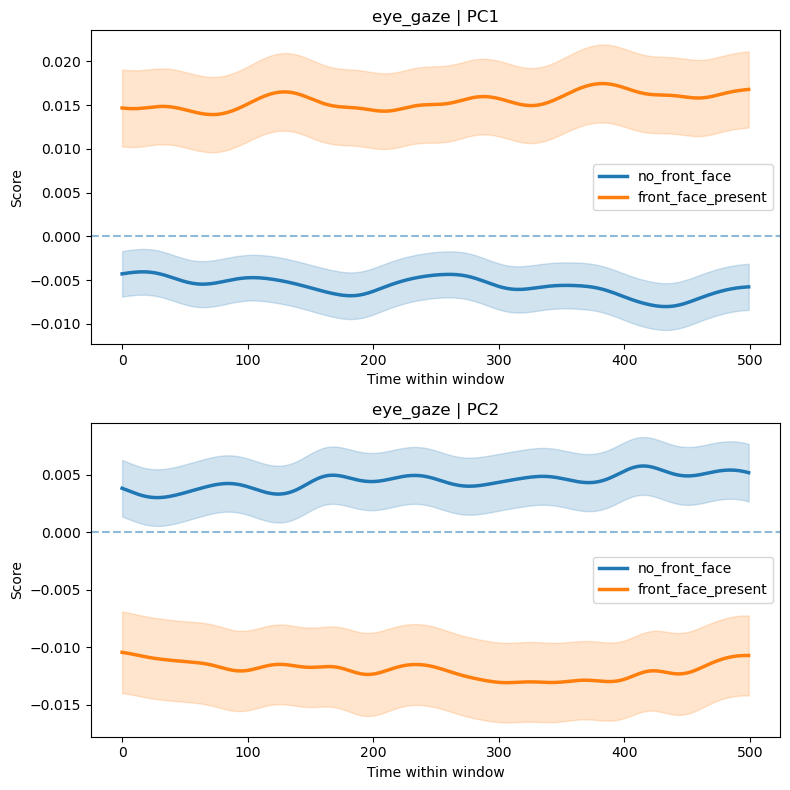

[pupil] [sub=47] split by: front_face
[pupil] [sub=47] no_front_face windows: 1111
[pupil] [sub=47] front_face_present windows: 409
[pupil] [sub=47] shared explained variance ratio: [1.]


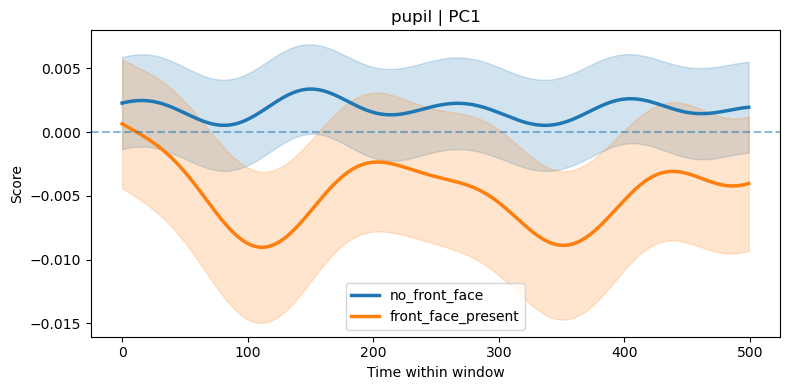

In [17]:
modality_keys = ["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"]
for mod in modality_keys:
    pca_res = decompose.run_grouped_trajectory_pca_on_concat_data(concat_data, spliter="front_face", eps=1.0, modality=mod, n_components=5, split_by_sub=True)

    # decompose.plot_grouped_pca_across_sub(pca_res, pcx=1, pcy=2, alpha=0.3, equal_axis=True)
    # decompose.plot_grouped_pca_across_sub(pca_res, pcx=2, pcy=3, alpha=0.3, equal_axis=True)
    decompose.plot_pc_time_series_across_sub(pca_res, pcs=(1,2))

    # decompose.run_decoding_on_pca_res(pca_res, mode="time_mean")
    # decompose.run_decoding_on_pca_res(pca_res, mode="stats")
    # decompose.run_decoding_on_pca_res(pca_res, mode="channel_mean")

## 4.2 Modality Fusion
### 4.2.1 Feature Summary

[split] sub=47: n_windows=1520
[firing_rate] X.shape=(1520, 825), valid=1520/1520
[lfp_macro] X.shape=(1520, 1056), valid=1520/1520
[lfp_micro] X.shape=(1520, 880), valid=1520/1520
[eye_gaze] X.shape=(1520, 22), valid=1520/1520
[pupil] X.shape=(1520, 11), valid=1520/1520
[subject PCA] sub=47, mod=firing_rate, X_use.shape=(1520, 825), Z.shape=(1520, 10)
[subject PCA] sub=47, mod=lfp_macro, X_use.shape=(1520, 1056), Z.shape=(1520, 10)
[subject PCA] sub=47, mod=lfp_micro, X_use.shape=(1520, 880), Z.shape=(1520, 10)
[subject PCA] sub=47, mod=eye_gaze, X_use.shape=(1520, 22), Z.shape=(1520, 10)
[subject PCA] sub=47, mod=pupil, X_use.shape=(1520, 11), Z.shape=(1520, 10)
[stack latent] mod=eye_gaze, shape=(1520, 10), K_common=10
[stack latent] mod=firing_rate, shape=(1520, 10), K_common=10
[stack latent] mod=lfp_macro, shape=(1520, 10), K_common=10
[stack latent] mod=lfp_micro, shape=(1520, 10), K_common=10
[stack latent] mod=pupil, shape=(1520, 10), K_common=10
[single latent] eye_gaze: AUC=

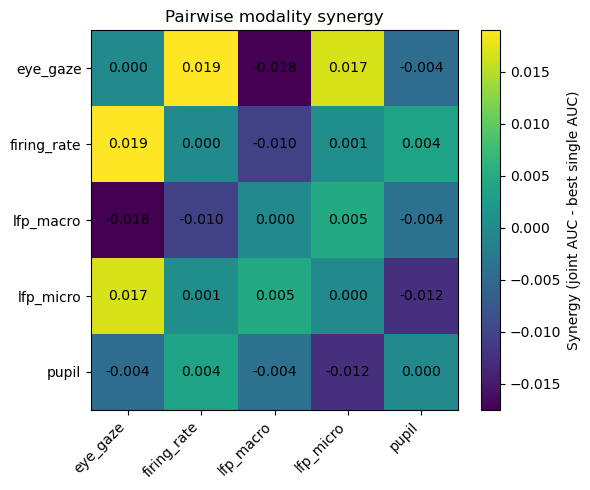

In [18]:
subject_latent_res = new_fusion.build_subjectwise_modality_latents(
    concat_data,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    feature_mode="stats_bandpower",
    pca_dim=10,
    sub_col="sub",
    verbose=True,
    fs=1000,
)

y_dict = new_fusion.get_label_dict_from_concat_data(
    concat_data,
    y_col="emo_neutral",
    sub_col="sub",
)

stacked_latent = new_fusion.stack_subjectwise_latents(
    subject_latent_res,
    y_dict=y_dict,
    verbose=True,
)

syn_res = new_fusion.compute_pairwise_synergy_matrix_from_latents(
    stacked_latent,
    cv=5,
    verbose=True,
)

new_fusion.plot_synergy_matrix(syn_res)

[stack latent] mod=eye_gaze, shape=(1520, 10), K_common=10
[stack latent] mod=firing_rate, shape=(1520, 10), K_common=10
[stack latent] mod=lfp_macro, shape=(1520, 10), K_common=10
[stack latent] mod=lfp_micro, shape=(1520, 10), K_common=10
[stack latent] mod=pupil, shape=(1520, 10), K_common=10
[single latent] eye_gaze: AUC=0.7190 ± 0.0289
[single latent] firing_rate: AUC=0.7307 ± 0.0259
[single latent] lfp_macro: AUC=0.6043 ± 0.0484
[single latent] lfp_micro: AUC=0.5921 ± 0.0421
[single latent] pupil: AUC=0.6027 ± 0.0342
[pair latent] eye_gaze+firing_rate: AUC=0.8002 ± 0.0118, synergy=0.0695
[pair latent] eye_gaze+lfp_macro: AUC=0.7199 ± 0.0180, synergy=0.0009
[pair latent] eye_gaze+lfp_micro: AUC=0.7289 ± 0.0201, synergy=0.0098
[pair latent] eye_gaze+pupil: AUC=0.7244 ± 0.0300, synergy=0.0054
[pair latent] firing_rate+lfp_macro: AUC=0.7354 ± 0.0302, synergy=0.0047
[pair latent] firing_rate+lfp_micro: AUC=0.7493 ± 0.0269, synergy=0.0186
[pair latent] firing_rate+pupil: AUC=0.7482 ± 0

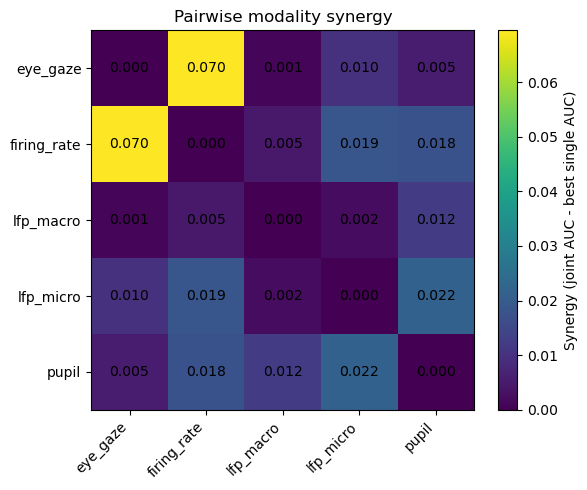

In [19]:
y_dict = new_fusion.get_label_dict_from_concat_data(
    concat_data,
    y_col="jacky_ratio",
    sub_col="sub",
)

stacked_latent = new_fusion.stack_subjectwise_latents(
    subject_latent_res,
    y_dict=y_dict,
    verbose=True,
)

syn_res = new_fusion.compute_pairwise_synergy_matrix_from_latents(
    stacked_latent,
    cv=5,
    verbose=True,
)

new_fusion.plot_synergy_matrix(syn_res)

[stack latent] mod=eye_gaze, shape=(1520, 10), K_common=10
[stack latent] mod=firing_rate, shape=(1520, 10), K_common=10
[stack latent] mod=lfp_macro, shape=(1520, 10), K_common=10
[stack latent] mod=lfp_micro, shape=(1520, 10), K_common=10
[stack latent] mod=pupil, shape=(1520, 10), K_common=10
[single latent] eye_gaze: AUC=0.6194 ± 0.0186
[single latent] firing_rate: AUC=0.6202 ± 0.0255
[single latent] lfp_macro: AUC=0.5231 ± 0.0348
[single latent] lfp_micro: AUC=0.5353 ± 0.0366
[single latent] pupil: AUC=0.5619 ± 0.0236
[pair latent] eye_gaze+firing_rate: AUC=0.6754 ± 0.0258, synergy=0.0552
[pair latent] eye_gaze+lfp_macro: AUC=0.6199 ± 0.0247, synergy=0.0006
[pair latent] eye_gaze+lfp_micro: AUC=0.6251 ± 0.0240, synergy=0.0058
[pair latent] eye_gaze+pupil: AUC=0.6172 ± 0.0218, synergy=-0.0021
[pair latent] firing_rate+lfp_macro: AUC=0.6153 ± 0.0269, synergy=-0.0048
[pair latent] firing_rate+lfp_micro: AUC=0.6231 ± 0.0314, synergy=0.0029
[pair latent] firing_rate+pupil: AUC=0.6393 ±

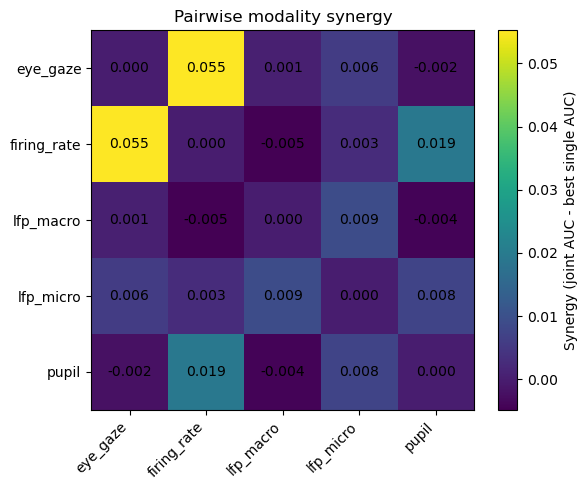

In [20]:
y_dict = new_fusion.get_label_dict_from_concat_data(
    concat_data,
    y_col="front_face_ratio",
    sub_col="sub",
)

stacked_latent = new_fusion.stack_subjectwise_latents(
    subject_latent_res,
    y_dict=y_dict,
    verbose=True,
)

syn_res = new_fusion.compute_pairwise_synergy_matrix_from_latents(
    stacked_latent,
    cv=5,
    verbose=True,
)

new_fusion.plot_synergy_matrix(syn_res)

## AUC Sanity Checking

In [21]:
import numpy as np
import pandas as pd
from itertools import combinations

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score


def _cv_auc(X, y, cv=5, random_state=42):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)

    model = make_pipeline(
        SimpleImputer(strategy="mean"),
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight="balanced")
    )

    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    aucs = cross_val_score(model, X, y, cv=skf, scoring="roc_auc")
    return float(np.mean(aucs)), float(np.std(aucs))


def sanity_check_single_modalities_multisub(
    feat_dict_by_sub,
    valid_mask_dict_by_sub,
    y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    min_windows=10,
    return_per_subject=True,
    verbose=True,
):
    """
    Parameters
    ----------
    feat_dict_by_sub : dict
        {
            sub1: {mod1: [N_sub, F], mod2: ...},
            sub2: ...
        }

    valid_mask_dict_by_sub : dict
        {
            sub1: {mod1: [N_sub] bool, mod2: ...},
            sub2: ...
        }

    y_dict : dict
        {
            sub1: [N_sub],
            sub2: [N_sub],
            ...
        }

    Returns
    -------
    summary_df : DataFrame
        one row per modality, aggregated across subjects

    per_sub_df : DataFrame
        one row per subject x modality
    """
    rng = np.random.default_rng(random_state)

    all_mods = sorted(list(set(
        m for sub in feat_dict_by_sub
        for m in feat_dict_by_sub[sub].keys()
    )))

    rows = []

    for sub in sorted(feat_dict_by_sub.keys()):
        if sub not in valid_mask_dict_by_sub:
            continue
        if sub not in y_dict:
            continue

        y = np.asarray(y_dict[sub])

        for mod in all_mods:
            if mod not in feat_dict_by_sub[sub]:
                continue
            if mod not in valid_mask_dict_by_sub[sub]:
                continue

            X = np.asarray(feat_dict_by_sub[sub][mod], dtype=float)
            mask = np.asarray(valid_mask_dict_by_sub[sub][mod], dtype=bool)

            if len(mask) != len(y):
                raise ValueError(
                    f"sub={sub}, mod={mod}: len(mask)={len(mask)} != len(y)={len(y)}"
                )
            if X.shape[0] != len(y):
                raise ValueError(
                    f"sub={sub}, mod={mod}: X.shape[0]={X.shape[0]} != len(y)={len(y)}"
                )

            mask = mask & np.isfinite(y)
            X_use = X[mask]
            y_use = y[mask]

            n_windows = int(mask.sum())
            n_classes = len(np.unique(y_use))

            if n_windows < max(cv, min_windows):
                if verbose:
                    print(f"[skip] sub={sub}, mod={mod}: too few windows ({n_windows})")
                continue

            if n_classes < 2:
                if verbose:
                    print(f"[skip] sub={sub}, mod={mod}: only one class")
                continue

            try:
                auc_mean, auc_std = _cv_auc(X_use, y_use, cv=cv, random_state=random_state)
            except Exception as e:
                if verbose:
                    print(f"[skip] sub={sub}, mod={mod}: CV failed ({e})")
                continue

            perm_aucs = []
            for _ in range(n_perm):
                y_perm = rng.permutation(y_use)
                try:
                    a, _ = _cv_auc(X_use, y_perm, cv=cv, random_state=random_state)
                    perm_aucs.append(a)
                except Exception:
                    pass

            perm_auc_mean = np.mean(perm_aucs) if len(perm_aucs) > 0 else np.nan
            perm_auc_std = np.std(perm_aucs) if len(perm_aucs) > 0 else np.nan

            rows.append({
                "sub": sub,
                "modality": mod,
                "n_windows": n_windows,
                "n_features": int(X_use.shape[1]),
                "auc_mean": auc_mean,
                "auc_std": auc_std,
                "perm_auc_mean": perm_auc_mean,
                "perm_auc_std": perm_auc_std,
                "delta_over_perm": auc_mean - perm_auc_mean if np.isfinite(perm_auc_mean) else np.nan,
            })

            if verbose:
                print(
                    f"[sub={sub}][{mod}] "
                    f"AUC={auc_mean:.4f}±{auc_std:.4f}, "
                    f"perm={perm_auc_mean:.4f}±{perm_auc_std:.4f}, "
                    f"delta={auc_mean - perm_auc_mean:.4f}"
                )

    per_sub_df = pd.DataFrame(rows)

    if len(per_sub_df) == 0:
        empty_cols = [
            "modality", "n_subjects", "mean_n_windows", "mean_n_features",
            "auc_mean_across_sub", "auc_std_across_sub",
            "perm_auc_mean_across_sub", "perm_auc_std_across_sub",
            "delta_over_perm_across_sub"
        ]
        summary_df = pd.DataFrame(columns=empty_cols)
        return (summary_df, per_sub_df) if return_per_subject else summary_df

    summary_df = (
        per_sub_df
        .groupby("modality", observed=True)
        .agg(
            n_subjects=("sub", "nunique"),
            mean_n_windows=("n_windows", "mean"),
            mean_n_features=("n_features", "mean"),
            auc_mean_across_sub=("auc_mean", "mean"),
            auc_std_across_sub=("auc_mean", "std"),
            perm_auc_mean_across_sub=("perm_auc_mean", "mean"),
            perm_auc_std_across_sub=("perm_auc_mean", "std"),
            delta_over_perm_across_sub=("delta_over_perm", "mean"),
        )
        .reset_index()
        .sort_values("auc_mean_across_sub", ascending=False)
        .reset_index(drop=True)
    )

    return (summary_df, per_sub_df) if return_per_subject else summary_df

def sanity_check_pairwise_synergy_multisub(
    feat_dict_by_sub,
    valid_mask_dict_by_sub,
    y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    min_windows=10,
    return_per_subject=True,
    verbose=True,
):
    """
    Multi-subject pairwise synergy check.

    Parameters
    ----------
    feat_dict_by_sub : dict
        {
            sub1: {mod1: [N_sub, F], mod2: ...},
            sub2: ...
        }

    valid_mask_dict_by_sub : dict
        {
            sub1: {mod1: [N_sub] bool, mod2: ...},
            sub2: ...
        }

    y_dict : dict
        {
            sub1: [N_sub],
            sub2: [N_sub],
            ...
        }

    Returns
    -------
    summary_df : DataFrame
        aggregated over subjects, one row per modality pair

    per_sub_df : DataFrame
        one row per subject x modality pair
    """
    rng = np.random.default_rng(random_state)

    all_mods = sorted(list(set(
        m for sub in feat_dict_by_sub
        for m in feat_dict_by_sub[sub].keys()
    )))

    rows = []

    for sub in sorted(feat_dict_by_sub.keys()):
        if sub not in valid_mask_dict_by_sub:
            continue
        if sub not in y_dict:
            continue

        feat_dict = feat_dict_by_sub[sub]
        valid_mask_dict = valid_mask_dict_by_sub[sub]
        y = np.asarray(y_dict[sub])

        # single-modality AUC
        single_auc = {}

        for mod in all_mods:
            if mod not in feat_dict or mod not in valid_mask_dict:
                single_auc[mod] = np.nan
                continue

            X = np.asarray(feat_dict[mod], dtype=float)
            mask = np.asarray(valid_mask_dict[mod], dtype=bool)

            if len(mask) != len(y):
                raise ValueError(
                    f"sub={sub}, mod={mod}: len(mask)={len(mask)} != len(y)={len(y)}"
                )
            if X.shape[0] != len(y):
                raise ValueError(
                    f"sub={sub}, mod={mod}: X.shape[0]={X.shape[0]} != len(y)={len(y)}"
                )

            mask = mask & np.isfinite(y)
            X_use = X[mask]
            y_use = y[mask]

            if int(mask.sum()) < max(cv, min_windows) or len(np.unique(y_use)) < 2:
                single_auc[mod] = np.nan
                continue

            try:
                single_auc[mod], _ = _cv_auc(X_use, y_use, cv=cv, random_state=random_state)
            except Exception:
                single_auc[mod] = np.nan

        # pairwise
        mods_sub = [m for m in all_mods if m in feat_dict and m in valid_mask_dict]

        for m1, m2 in combinations(mods_sub, 2):
            mask = (
                np.asarray(valid_mask_dict[m1], dtype=bool)
                & np.asarray(valid_mask_dict[m2], dtype=bool)
                & np.isfinite(y)
            )

            n_windows = int(mask.sum())
            if n_windows < max(cv, min_windows):
                if verbose:
                    print(f"[skip] sub={sub}, {m1}+{m2}: too few windows ({n_windows})")
                continue

            y_use = y[mask]
            if len(np.unique(y_use)) < 2:
                if verbose:
                    print(f"[skip] sub={sub}, {m1}+{m2}: only one class")
                continue

            X1 = np.asarray(feat_dict[m1], dtype=float)[mask]
            X2 = np.asarray(feat_dict[m2], dtype=float)[mask]
            X_joint = np.concatenate([X1, X2], axis=1)

            try:
                joint_auc, joint_std = _cv_auc(X_joint, y_use, cv=cv, random_state=random_state)
            except Exception as e:
                if verbose:
                    print(f"[skip] sub={sub}, {m1}+{m2}: CV failed ({e})")
                continue

            best_single = np.nanmax([single_auc.get(m1, np.nan), single_auc.get(m2, np.nan)])
            synergy = joint_auc - best_single if np.isfinite(best_single) else np.nan

            perm_joint_aucs = []
            for _ in range(n_perm):
                y_perm = rng.permutation(y_use)
                try:
                    a, _ = _cv_auc(X_joint, y_perm, cv=cv, random_state=random_state)
                    perm_joint_aucs.append(a)
                except Exception:
                    pass

            perm_joint_mean = np.mean(perm_joint_aucs) if len(perm_joint_aucs) > 0 else np.nan
            perm_joint_std = np.std(perm_joint_aucs) if len(perm_joint_aucs) > 0 else np.nan

            rows.append({
                "sub": sub,
                "mod1": m1,
                "mod2": m2,
                "n_windows": n_windows,
                "n_features_joint": int(X_joint.shape[1]),
                "joint_auc": joint_auc,
                "joint_std": joint_std,
                "best_single_auc": best_single,
                "synergy": synergy,
                "perm_joint_auc_mean": perm_joint_mean,
                "perm_joint_auc_std": perm_joint_std,
                "synergy_vs_perm_joint": joint_auc - perm_joint_mean if np.isfinite(perm_joint_mean) else np.nan,
            })

            if verbose:
                print(
                    f"[sub={sub}][{m1}+{m2}] "
                    f"joint={joint_auc:.4f}, "
                    f"best_single={best_single:.4f}, "
                    f"synergy={synergy:.4f}, "
                    f"vs_perm={joint_auc - perm_joint_mean:.4f}"
                )

    per_sub_df = pd.DataFrame(rows)

    if len(per_sub_df) == 0:
        empty_cols = [
            "mod1", "mod2", "pair", "n_subjects", "mean_n_windows",
            "joint_auc_across_sub", "joint_auc_std_across_sub",
            "best_single_auc_across_sub", "synergy_across_sub",
            "perm_joint_auc_mean_across_sub", "synergy_vs_perm_joint_across_sub"
        ]
        summary_df = pd.DataFrame(columns=empty_cols)
        return (summary_df, per_sub_df) if return_per_subject else summary_df

    per_sub_df["pair"] = per_sub_df["mod1"].astype(str) + " + " + per_sub_df["mod2"].astype(str)

    summary_df = (
        per_sub_df
        .groupby(["mod1", "mod2", "pair"], observed=True)
        .agg(
            n_subjects=("sub", "nunique"),
            mean_n_windows=("n_windows", "mean"),
            joint_auc_across_sub=("joint_auc", "mean"),
            joint_auc_std_across_sub=("joint_auc", "std"),
            best_single_auc_across_sub=("best_single_auc", "mean"),
            synergy_across_sub=("synergy", "mean"),
            synergy_std_across_sub=("synergy", "std"),
            perm_joint_auc_mean_across_sub=("perm_joint_auc_mean", "mean"),
            synergy_vs_perm_joint_across_sub=("synergy_vs_perm_joint", "mean"),
        )
        .reset_index()
        .sort_values("synergy_across_sub", ascending=False)
        .reset_index(drop=True)
    )

    return (summary_df, per_sub_df) if return_per_subject else summary_df

def extract_feat_inputs_from_subject_latent_res(subject_latent_res, use_latent=False):
    """
    use_latent=False -> 用 feat_dict
    use_latent=True  -> 用 latent_dict
    """
    feat_dict_by_sub = {}
    valid_mask_dict_by_sub = {}

    for sub, res in subject_latent_res.items():
        feat_dict_by_sub[sub] = res["latent_dict"] if use_latent else res["feat_dict"]
        valid_mask_dict_by_sub[sub] = res["valid_mask_dict"]

    return feat_dict_by_sub, valid_mask_dict_by_sub

In [22]:
y_dict = new_fusion.get_label_dict_from_concat_data(
    concat_data,
    y_col="jacky_ratio",
    sub_col="sub",
)

feat_dict_by_sub, valid_mask_dict_by_sub = extract_feat_inputs_from_subject_latent_res(
    subject_latent_res,
    use_latent=False,
)

single_summary_df, single_per_sub_df = sanity_check_single_modalities_multisub(
    feat_dict_by_sub=feat_dict_by_sub,
    valid_mask_dict_by_sub=valid_mask_dict_by_sub,
    y_dict=y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    verbose=True,
)
display(single_summary_df)

pair_summary_df, pair_per_sub_df = sanity_check_pairwise_synergy_multisub(
    feat_dict_by_sub=feat_dict_by_sub,
    valid_mask_dict_by_sub=valid_mask_dict_by_sub,
    y_dict=y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    verbose=True,
)

display(pair_summary_df)

[sub=47][eye_gaze] AUC=0.7210±0.0257, perm=0.4998±0.0196, delta=0.2212
[sub=47][firing_rate] AUC=0.6830±0.0177, perm=0.4978±0.0251, delta=0.1852
[sub=47][lfp_macro] AUC=0.5809±0.0489, perm=0.5074±0.0196, delta=0.0735
[sub=47][lfp_micro] AUC=0.5807±0.0293, perm=0.5020±0.0182, delta=0.0787
[sub=47][pupil] AUC=0.6033±0.0350, perm=0.4943±0.0248, delta=0.1090


,modality,n_subjects,mean_n_windows,mean_n_features,auc_mean_across_sub,auc_std_across_sub,perm_auc_mean_across_sub,perm_auc_std_across_sub,delta_over_perm_across_sub
0,eye_gaze,1,1520.0,22.0,0.721007,NaN,0.499806,NaN,0.221202
1,firing_rate,1,1520.0,825.0,0.682963,NaN,0.497768,NaN,0.185195
2,pupil,1,1520.0,11.0,0.603271,NaN,0.494277,NaN,0.108995
3,lfp_macro,1,1520.0,1056.0,0.580912,NaN,0.507413,NaN,0.073499
4,lfp_micro,1,1520.0,880.0,0.580678,NaN,0.501985,NaN,0.078693


[sub=47][eye_gaze+firing_rate] joint=0.7125, best_single=0.7210, synergy=-0.0086, vs_perm=0.2159
[sub=47][eye_gaze+lfp_macro] joint=0.6454, best_single=0.7210, synergy=-0.0756, vs_perm=0.1431
[sub=47][eye_gaze+lfp_micro] joint=0.6273, best_single=0.7210, synergy=-0.0937, vs_perm=0.1244
[sub=47][eye_gaze+pupil] joint=0.7243, best_single=0.7210, synergy=0.0033, vs_perm=0.2189
[sub=47][firing_rate+lfp_macro] joint=0.7203, best_single=0.6830, synergy=0.0373, vs_perm=0.2142
[sub=47][firing_rate+lfp_micro] joint=0.7212, best_single=0.6830, synergy=0.0382, vs_perm=0.2204
[sub=47][firing_rate+pupil] joint=0.6899, best_single=0.6830, synergy=0.0069, vs_perm=0.1884
[sub=47][lfp_macro+lfp_micro] joint=0.6414, best_single=0.5809, synergy=0.0605, vs_perm=0.1450
[sub=47][lfp_macro+pupil] joint=0.6018, best_single=0.6033, synergy=-0.0014, vs_perm=0.1002
[sub=47][lfp_micro+pupil] joint=0.5979, best_single=0.6033, synergy=-0.0054, vs_perm=0.0927


,mod1,mod2,pair,n_subjects,mean_n_windows,joint_auc_across_sub,joint_auc_std_across_sub,best_single_auc_across_sub,synergy_across_sub,synergy_std_across_sub,perm_joint_auc_mean_across_sub,synergy_vs_perm_joint_across_sub
0,lfp_macro,lfp_micro,lfp_macro + lfp_micro,1,1520.0,0.641403,NaN,0.580912,0.060491,NaN,0.496395,0.145007
1,firing_rate,lfp_micro,firing_rate + lfp_micro,1,1520.0,0.721159,NaN,0.682963,0.038196,NaN,0.500728,0.220431
2,firing_rate,lfp_macro,firing_rate + lfp_macro,1,1520.0,0.720296,NaN,0.682963,0.037333,NaN,0.506059,0.214237
3,firing_rate,pupil,firing_rate + pupil,1,1520.0,0.689853,NaN,0.682963,0.006890,NaN,0.501409,0.188444
4,eye_gaze,pupil,eye_gaze + pupil,1,1520.0,0.724280,NaN,0.721007,0.003273,NaN,0.505361,0.218919
5,lfp_macro,pupil,lfp_macro + pupil,1,1520.0,0.601845,NaN,0.603271,-0.001426,NaN,0.501626,0.100219
6,lfp_micro,pupil,lfp_micro + pupil,1,1520.0,0.597862,NaN,0.603271,-0.005410,NaN,0.505151,0.092711
7,eye_gaze,firing_rate,eye_gaze + firing_rate,1,1520.0,0.712450,NaN,0.721007,-0.008557,NaN,0.496507,0.215943
8,eye_gaze,lfp_macro,eye_gaze + lfp_macro,1,1520.0,0.645425,NaN,0.721007,-0.075583,NaN,0.502334,0.143090
9,eye_gaze,lfp_micro,eye_gaze + lfp_micro,1,1520.0,0.627274,NaN,0.721007,-0.093733,NaN,0.502892,0.124382


In [23]:
y_dict = new_fusion.get_label_dict_from_concat_data(
    concat_data,
    y_col="front_face_ratio",
    sub_col="sub",
)

feat_dict_by_sub, valid_mask_dict_by_sub = extract_feat_inputs_from_subject_latent_res(
    subject_latent_res,
    use_latent=False,
)

single_summary_df, single_per_sub_df = sanity_check_single_modalities_multisub(
    feat_dict_by_sub=feat_dict_by_sub,
    valid_mask_dict_by_sub=valid_mask_dict_by_sub,
    y_dict=y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    verbose=True,
)
display(single_summary_df)

pair_summary_df, pair_per_sub_df = sanity_check_pairwise_synergy_multisub(
    feat_dict_by_sub=feat_dict_by_sub,
    valid_mask_dict_by_sub=valid_mask_dict_by_sub,
    y_dict=y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    verbose=True,
)

display(pair_summary_df)

[sub=47][eye_gaze] AUC=0.6203±0.0193, perm=0.5029±0.0181, delta=0.1174
[sub=47][firing_rate] AUC=0.6493±0.0335, perm=0.5052±0.0124, delta=0.1440
[sub=47][lfp_macro] AUC=0.5764±0.0283, perm=0.5027±0.0164, delta=0.0738
[sub=47][lfp_micro] AUC=0.5837±0.0315, perm=0.5079±0.0161, delta=0.0757
[sub=47][pupil] AUC=0.5631±0.0244, perm=0.5034±0.0245, delta=0.0598


,modality,n_subjects,mean_n_windows,mean_n_features,auc_mean_across_sub,auc_std_across_sub,perm_auc_mean_across_sub,perm_auc_std_across_sub,delta_over_perm_across_sub
0,firing_rate,1,1520.0,825.0,0.649264,NaN,0.505241,NaN,0.144023
1,eye_gaze,1,1520.0,22.0,0.620264,NaN,0.502889,NaN,0.117375
2,lfp_micro,1,1520.0,880.0,0.583653,NaN,0.507913,NaN,0.075741
3,lfp_macro,1,1520.0,1056.0,0.576440,NaN,0.502660,NaN,0.073781
4,pupil,1,1520.0,11.0,0.563113,NaN,0.503357,NaN,0.059756


[sub=47][eye_gaze+firing_rate] joint=0.6699, best_single=0.6493, synergy=0.0207, vs_perm=0.1740
[sub=47][eye_gaze+lfp_macro] joint=0.5921, best_single=0.6203, synergy=-0.0282, vs_perm=0.0931
[sub=47][eye_gaze+lfp_micro] joint=0.6230, best_single=0.6203, synergy=0.0027, vs_perm=0.1301
[sub=47][eye_gaze+pupil] joint=0.6166, best_single=0.6203, synergy=-0.0037, vs_perm=0.1177
[sub=47][firing_rate+lfp_macro] joint=0.6551, best_single=0.6493, synergy=0.0058, vs_perm=0.1538
[sub=47][firing_rate+lfp_micro] joint=0.6212, best_single=0.6493, synergy=-0.0281, vs_perm=0.1212
[sub=47][firing_rate+pupil] joint=0.6511, best_single=0.6493, synergy=0.0019, vs_perm=0.1515
[sub=47][lfp_macro+lfp_micro] joint=0.6109, best_single=0.5837, synergy=0.0273, vs_perm=0.1106
[sub=47][lfp_macro+pupil] joint=0.5830, best_single=0.5764, synergy=0.0066, vs_perm=0.0749
[sub=47][lfp_micro+pupil] joint=0.5976, best_single=0.5837, synergy=0.0140, vs_perm=0.1009


,mod1,mod2,pair,n_subjects,mean_n_windows,joint_auc_across_sub,joint_auc_std_across_sub,best_single_auc_across_sub,synergy_across_sub,synergy_std_across_sub,perm_joint_auc_mean_across_sub,synergy_vs_perm_joint_across_sub
0,lfp_macro,lfp_micro,lfp_macro + lfp_micro,1,1520.0,0.610946,NaN,0.583653,0.027292,NaN,0.500347,0.110599
1,eye_gaze,firing_rate,eye_gaze + firing_rate,1,1520.0,0.669941,NaN,0.649264,0.020677,NaN,0.495930,0.174010
2,lfp_micro,pupil,lfp_micro + pupil,1,1520.0,0.597642,NaN,0.583653,0.013989,NaN,0.496742,0.100900
3,lfp_macro,pupil,lfp_macro + pupil,1,1520.0,0.583005,NaN,0.576440,0.006565,NaN,0.508063,0.074942
4,firing_rate,lfp_macro,firing_rate + lfp_macro,1,1520.0,0.655087,NaN,0.649264,0.005823,NaN,0.501318,0.153768
5,eye_gaze,lfp_micro,eye_gaze + lfp_micro,1,1520.0,0.622980,NaN,0.620264,0.002716,NaN,0.492866,0.130114
6,firing_rate,pupil,firing_rate + pupil,1,1520.0,0.651121,NaN,0.649264,0.001858,NaN,0.499580,0.151541
7,eye_gaze,pupil,eye_gaze + pupil,1,1520.0,0.616592,NaN,0.620264,-0.003672,NaN,0.498931,0.117661
8,firing_rate,lfp_micro,firing_rate + lfp_micro,1,1520.0,0.621202,NaN,0.649264,-0.028061,NaN,0.500042,0.121160
9,eye_gaze,lfp_macro,eye_gaze + lfp_macro,1,1520.0,0.592076,NaN,0.620264,-0.028188,NaN,0.498990,0.093086


In [24]:
y_dict = new_fusion.get_label_dict_from_concat_data(
    concat_data,
    y_col="emo_neutral",
    sub_col="sub",
)

feat_dict_by_sub, valid_mask_dict_by_sub = extract_feat_inputs_from_subject_latent_res(
    subject_latent_res,
    use_latent=False,
)

single_summary_df, single_per_sub_df = sanity_check_single_modalities_multisub(
    feat_dict_by_sub=feat_dict_by_sub,
    valid_mask_dict_by_sub=valid_mask_dict_by_sub,
    y_dict=y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    verbose=True,
)
display(single_summary_df)

pair_summary_df, pair_per_sub_df = sanity_check_pairwise_synergy_multisub(
    feat_dict_by_sub=feat_dict_by_sub,
    valid_mask_dict_by_sub=valid_mask_dict_by_sub,
    y_dict=y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    verbose=True,
)

display(pair_summary_df)

[sub=47][eye_gaze] AUC=0.6782±0.0497, perm=0.4858±0.0414, delta=0.1924
[sub=47][firing_rate] AUC=0.8078±0.0293, perm=0.5013±0.0456, delta=0.3065
[sub=47][lfp_macro] AUC=0.6323±0.0328, perm=0.5128±0.0354, delta=0.1195
[sub=47][lfp_micro] AUC=0.6742±0.0792, perm=0.5005±0.0311, delta=0.1738
[sub=47][pupil] AUC=0.5257±0.0382, perm=0.5025±0.0294, delta=0.0232


,modality,n_subjects,mean_n_windows,mean_n_features,auc_mean_across_sub,auc_std_across_sub,perm_auc_mean_across_sub,perm_auc_std_across_sub,delta_over_perm_across_sub
0,firing_rate,1,1520.0,825.0,0.807776,NaN,0.501280,NaN,0.306496
1,eye_gaze,1,1520.0,22.0,0.678181,NaN,0.485790,NaN,0.192390
2,lfp_micro,1,1520.0,880.0,0.674226,NaN,0.500475,NaN,0.173751
3,lfp_macro,1,1520.0,1056.0,0.632315,NaN,0.512810,NaN,0.119505
4,pupil,1,1520.0,11.0,0.525683,NaN,0.502484,NaN,0.023200


[sub=47][eye_gaze+firing_rate] joint=0.8187, best_single=0.8078, synergy=0.0109, vs_perm=0.3201
[sub=47][eye_gaze+lfp_macro] joint=0.6753, best_single=0.6782, synergy=-0.0029, vs_perm=0.1699
[sub=47][eye_gaze+lfp_micro] joint=0.6896, best_single=0.6782, synergy=0.0114, vs_perm=0.1797
[sub=47][eye_gaze+pupil] joint=0.6732, best_single=0.6782, synergy=-0.0049, vs_perm=0.1783
[sub=47][firing_rate+lfp_macro] joint=0.8343, best_single=0.8078, synergy=0.0265, vs_perm=0.3393
[sub=47][firing_rate+lfp_micro] joint=0.8350, best_single=0.8078, synergy=0.0272, vs_perm=0.3339
[sub=47][firing_rate+pupil] joint=0.8027, best_single=0.8078, synergy=-0.0051, vs_perm=0.3082
[sub=47][lfp_macro+lfp_micro] joint=0.7085, best_single=0.6742, synergy=0.0342, vs_perm=0.2166
[sub=47][lfp_macro+pupil] joint=0.6344, best_single=0.6323, synergy=0.0020, vs_perm=0.1355
[sub=47][lfp_micro+pupil] joint=0.6741, best_single=0.6742, synergy=-0.0001, vs_perm=0.1760


,mod1,mod2,pair,n_subjects,mean_n_windows,joint_auc_across_sub,joint_auc_std_across_sub,best_single_auc_across_sub,synergy_across_sub,synergy_std_across_sub,perm_joint_auc_mean_across_sub,synergy_vs_perm_joint_across_sub
0,lfp_macro,lfp_micro,lfp_macro + lfp_micro,1,1520.0,0.708473,NaN,0.674226,0.034247,NaN,0.491836,0.216637
1,firing_rate,lfp_micro,firing_rate + lfp_micro,1,1520.0,0.834988,NaN,0.807776,0.027213,NaN,0.501093,0.333896
2,firing_rate,lfp_macro,firing_rate + lfp_macro,1,1520.0,0.834274,NaN,0.807776,0.026499,NaN,0.494999,0.339276
3,eye_gaze,lfp_micro,eye_gaze + lfp_micro,1,1520.0,0.689615,NaN,0.678181,0.011435,NaN,0.509920,0.179695
4,eye_gaze,firing_rate,eye_gaze + firing_rate,1,1520.0,0.818694,NaN,0.807776,0.010918,NaN,0.498604,0.320090
5,lfp_macro,pupil,lfp_macro + pupil,1,1520.0,0.634363,NaN,0.632315,0.002048,NaN,0.498837,0.135526
6,lfp_micro,pupil,lfp_micro + pupil,1,1520.0,0.674085,NaN,0.674226,-0.000140,NaN,0.498058,0.176027
7,eye_gaze,lfp_macro,eye_gaze + lfp_macro,1,1520.0,0.675281,NaN,0.678181,-0.002900,NaN,0.505371,0.169910
8,eye_gaze,pupil,eye_gaze + pupil,1,1520.0,0.673234,NaN,0.678181,-0.004946,NaN,0.494960,0.178274
9,firing_rate,pupil,firing_rate + pupil,1,1520.0,0.802657,NaN,0.807776,-0.005119,NaN,0.494425,0.308232


## CCA

[subject CCA] sub=47, firing_rate vs lfp_macro: 0.335, 0.262, 0.151
[subject CCA] sub=47, firing_rate vs lfp_micro: 0.371, 0.307, 0.229
[subject CCA] sub=47, firing_rate vs eye_gaze: 0.316, 0.197, 0.155
[subject CCA] sub=47, firing_rate vs pupil: 0.272, 0.232, 0.118
[subject CCA] sub=47, lfp_macro vs lfp_micro: 0.546, 0.453, 0.418
[subject CCA] sub=47, lfp_macro vs eye_gaze: 0.391, 0.242, 0.200
[subject CCA] sub=47, lfp_macro vs pupil: 0.493, 0.180, 0.152
[subject CCA] sub=47, lfp_micro vs eye_gaze: 0.272, 0.162, 0.148
[subject CCA] sub=47, lfp_micro vs pupil: 0.520, 0.259, 0.194
[subject CCA] sub=47, eye_gaze vs pupil: 0.672, 0.492, 0.288


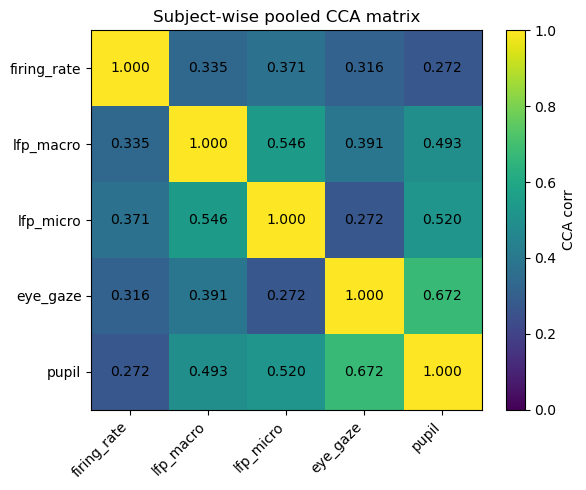

In [25]:
cca_res = new_fusion.compute_pairwise_cca_subjectwise(
    subject_latent_res,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    n_components=3,
    min_windows=20,
    verbose=True,
)

new_fusion.plot_cca_corr_heatmap_from_matrix(
    cca_res,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    mode="first",
    title="Subject-wise pooled CCA matrix",
)

# new_fusion.plot_cca_pair_scatter(
#     cca_res,
#     "firing_rate",
#     "eye_gaze",
#     comp=1,
# )

[time-PCA] sub=47, modality=firing_rate, X=(1520, 500, 75), Z=(1520, 500, 5)
[time-PCA] sub=47, modality=lfp_macro, X=(1520, 500, 96), Z=(1520, 500, 5)
[time-PCA] sub=47, modality=lfp_micro, X=(1520, 500, 80), Z=(1520, 500, 5)
[time-PCA] sub=47, modality=eye_gaze, X=(1520, 500, 2), Z=(1520, 500, 2)
[time-PCA] sub=47, modality=pupil, X=(1520, 500, 1), Z=(1520, 500, 1)
[time-CCA] sub=47, firing_rate vs lfp_macro, N=1520, T=500, Kc=3, corrs=0.011, 0.007, 0.004
[time-CCA] sub=47, firing_rate vs lfp_micro, N=1520, T=500, Kc=3, corrs=0.013, 0.008, 0.005
[time-CCA] sub=47, firing_rate vs eye_gaze, N=1520, T=500, Kc=2, corrs=0.013, 0.006
[time-CCA] sub=47, firing_rate vs pupil, N=1520, T=500, Kc=1, corrs=0.012
[time-CCA] sub=47, lfp_macro vs lfp_micro, N=1520, T=500, Kc=3, corrs=0.638, 0.268, 0.234
[time-CCA] sub=47, lfp_macro vs eye_gaze, N=1520, T=500, Kc=2, corrs=0.089, 0.058
[time-CCA] sub=47, lfp_macro vs pupil, N=1520, T=500, Kc=1, corrs=0.068
[time-CCA] sub=47, lfp_micro vs eye_gaze, N=

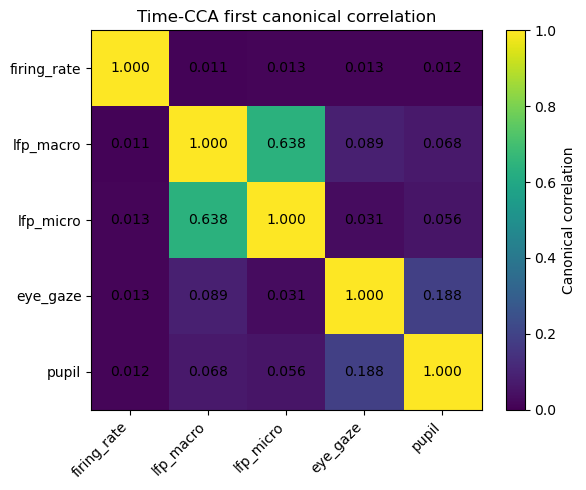

In [26]:
modality_keys = ["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"]

subject_time_pca_res = new_fusion.run_multimodal_subjectwise_time_trajectory_pca(
    concat_data,
    modality_keys=modality_keys,
    n_components=5,
    sub_col="sub",
    standardize=True,
    verbose=True,
)

time_cca_res = new_fusion.compute_pairwise_time_cca_subjectwise(
    subject_time_pca_res,
    modality_keys=modality_keys,
    n_components=3,
    min_windows=10,
    max_iter=2000,
    verbose=True,
)

new_fusion.plot_time_cca_synergy_matrix(
    time_cca_res,
    modality_keys=modality_keys,
    mode="first",
    title="Time-CCA first canonical correlation"
)

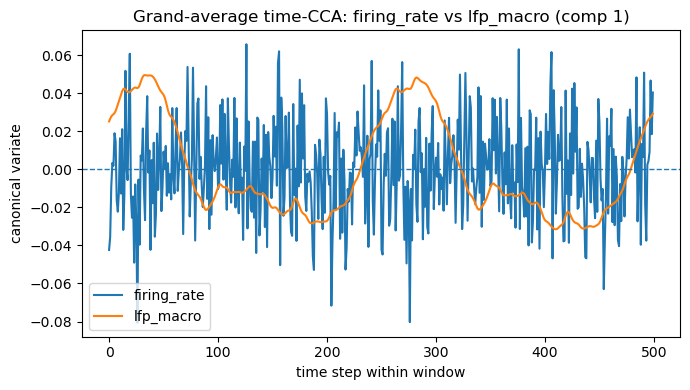

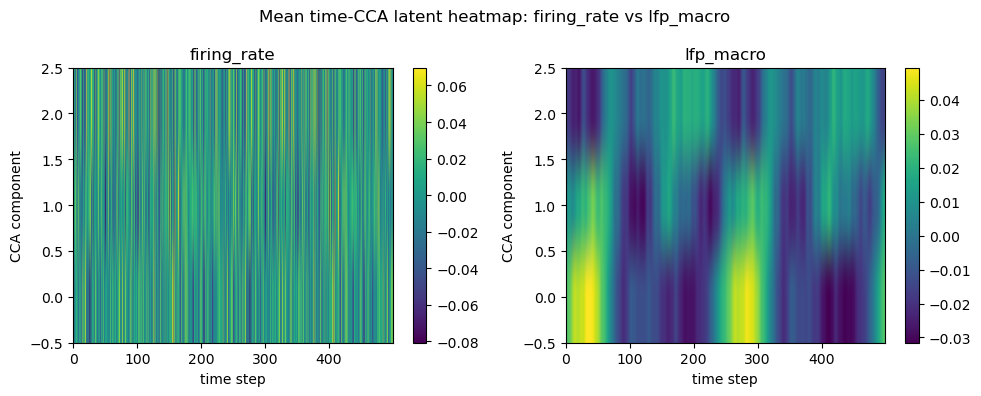

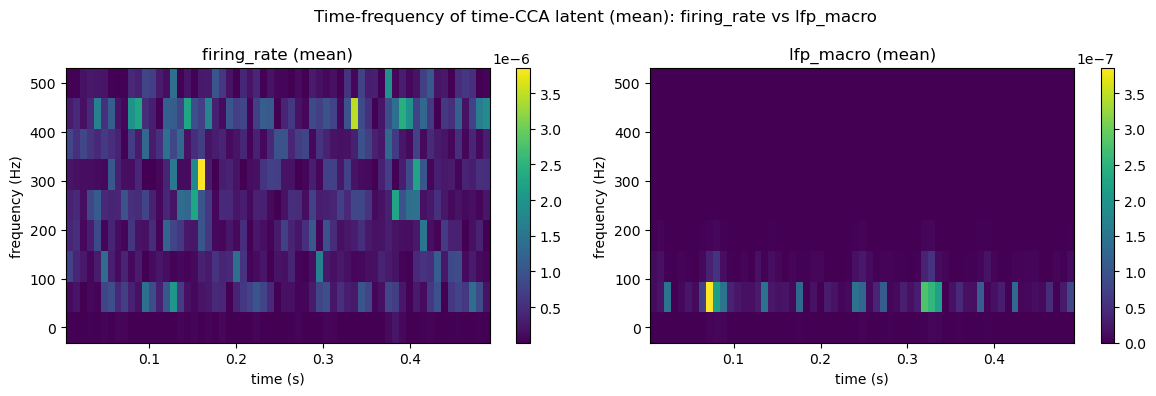

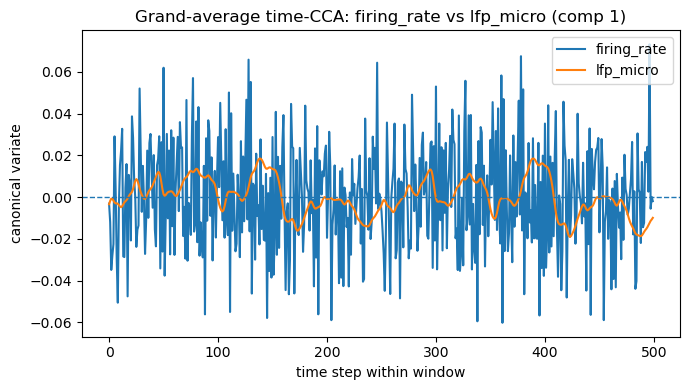

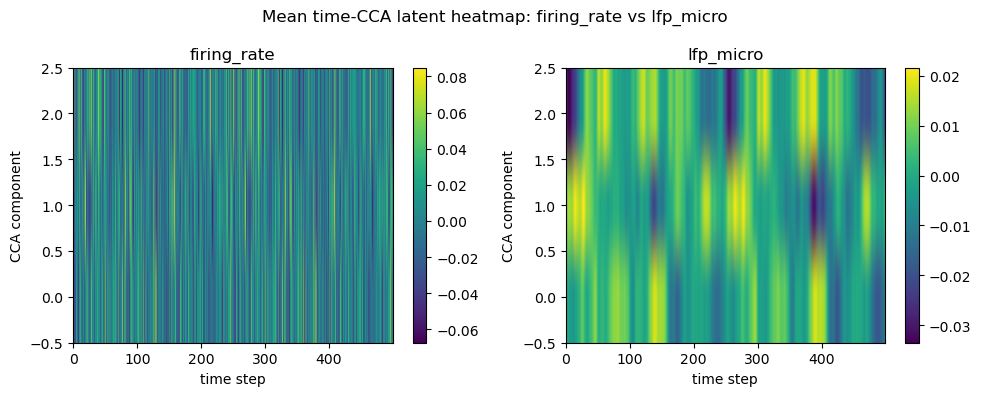

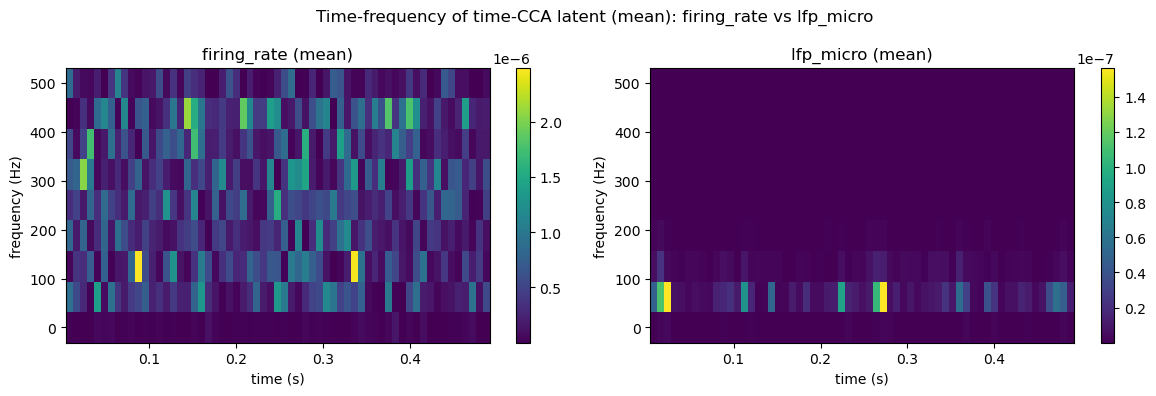

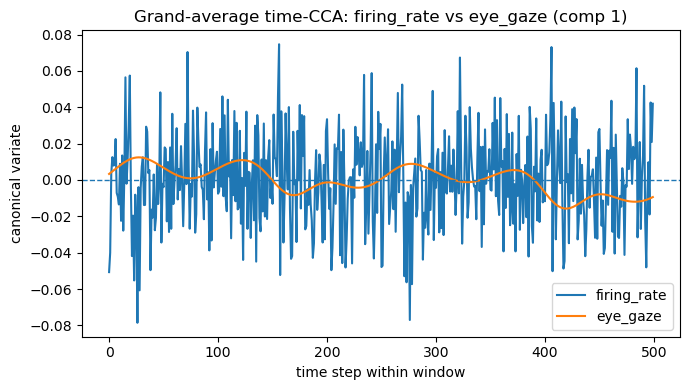

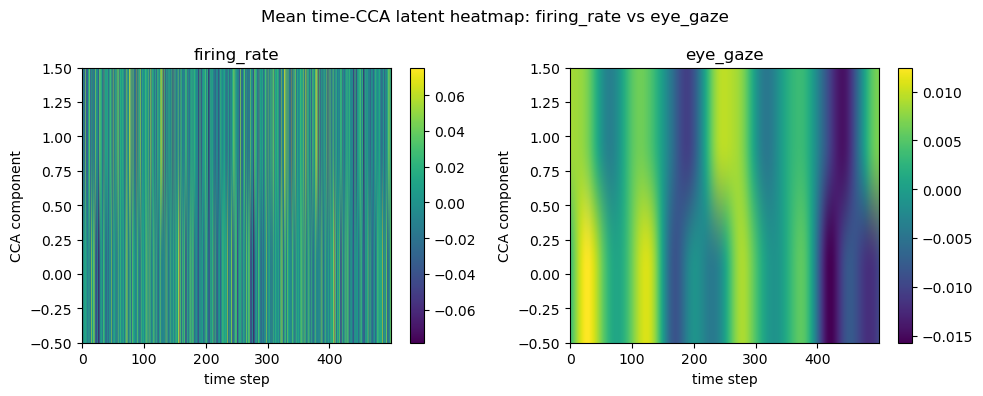

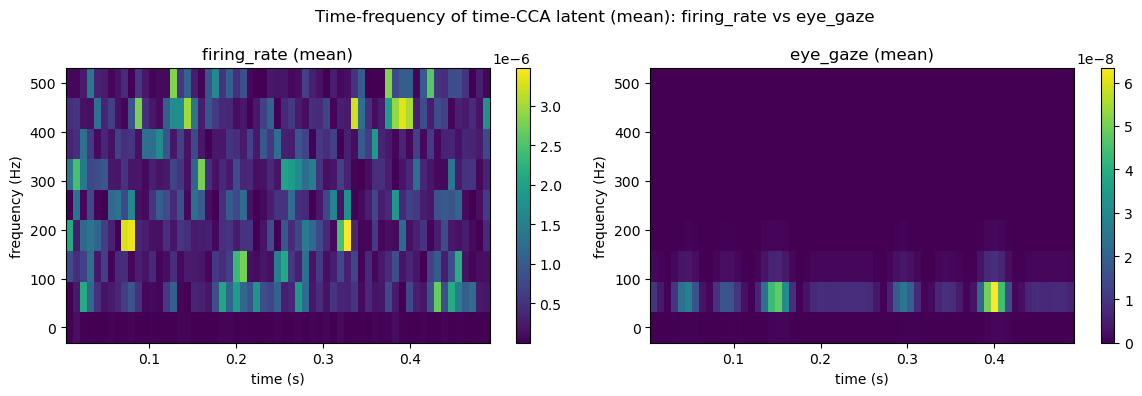

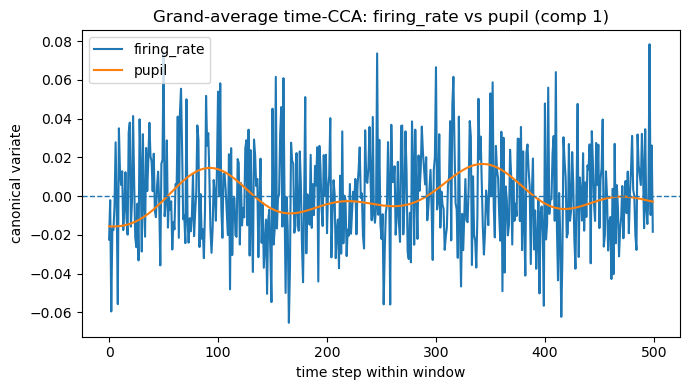

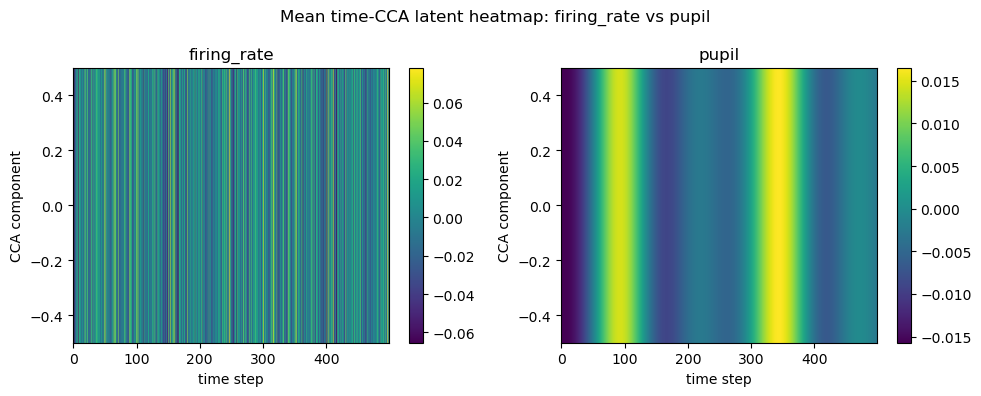

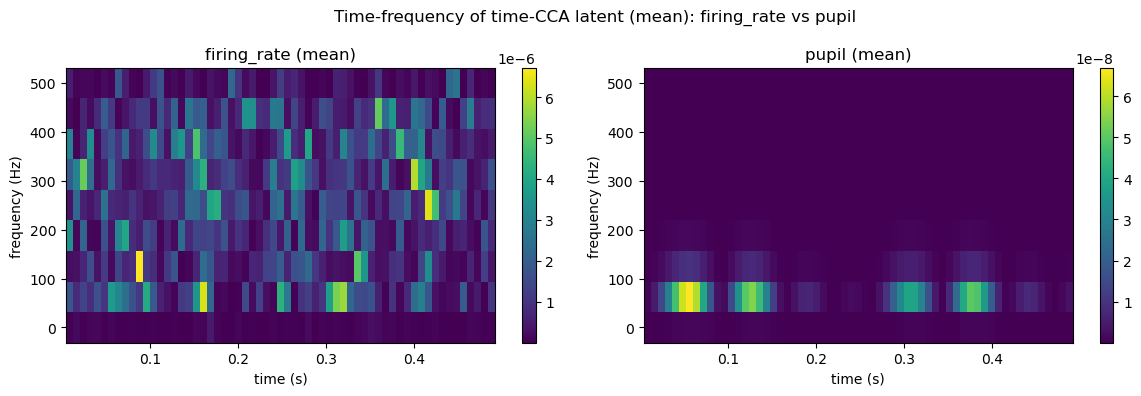

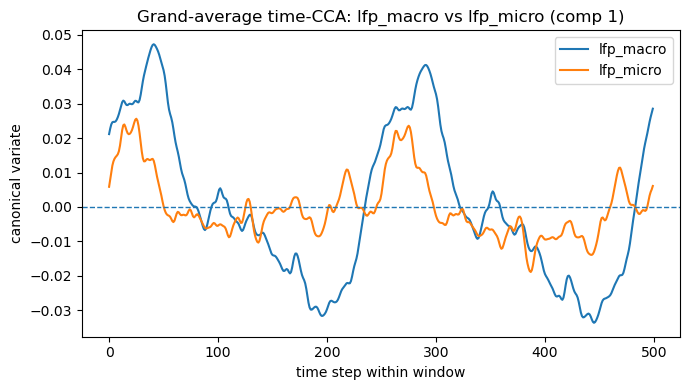

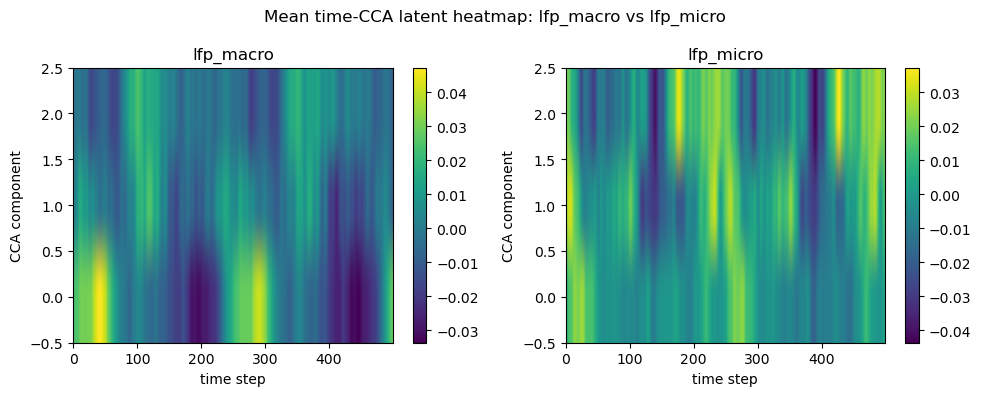

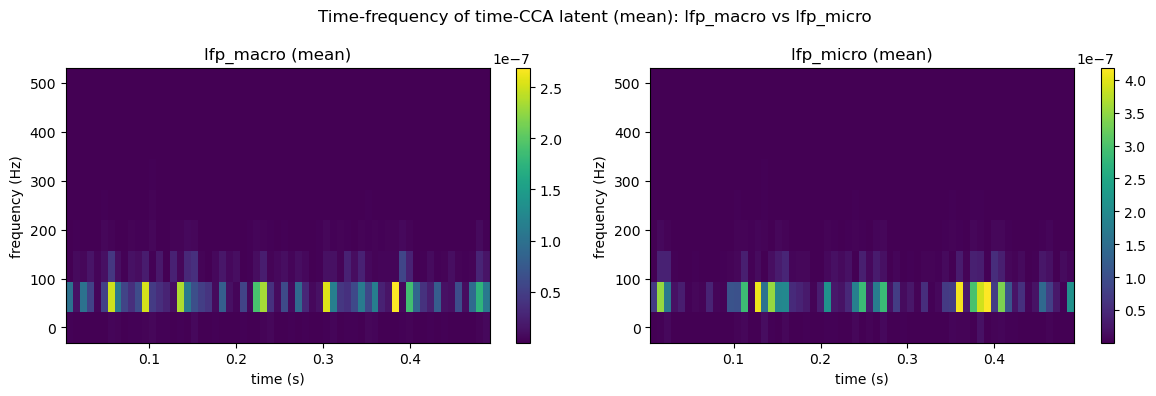

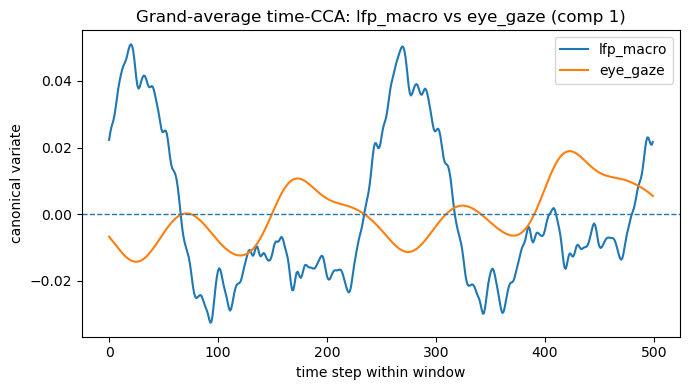

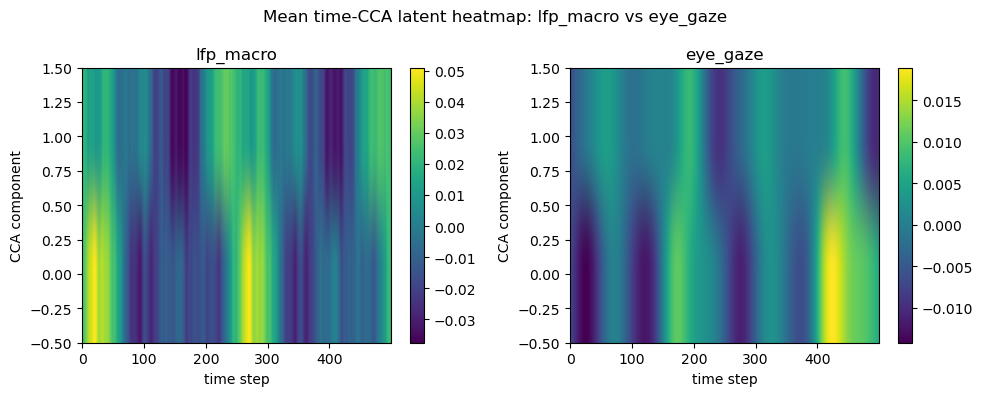

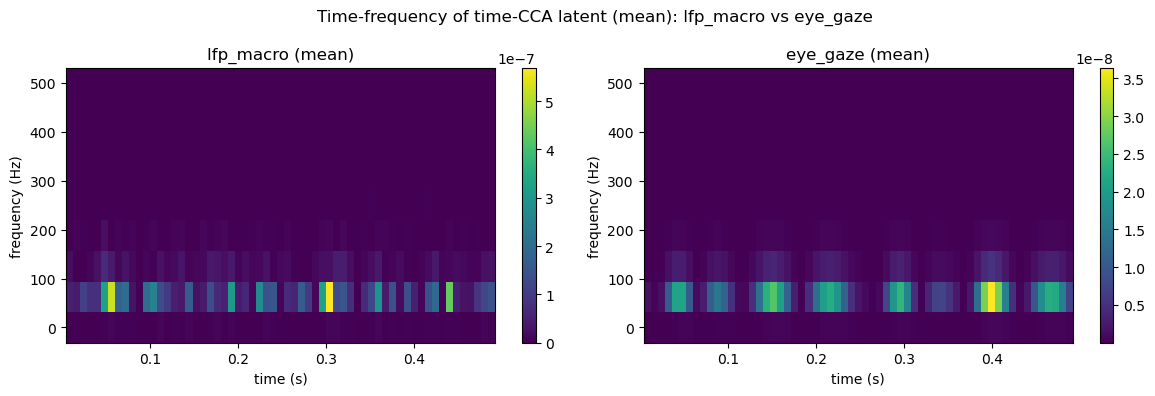

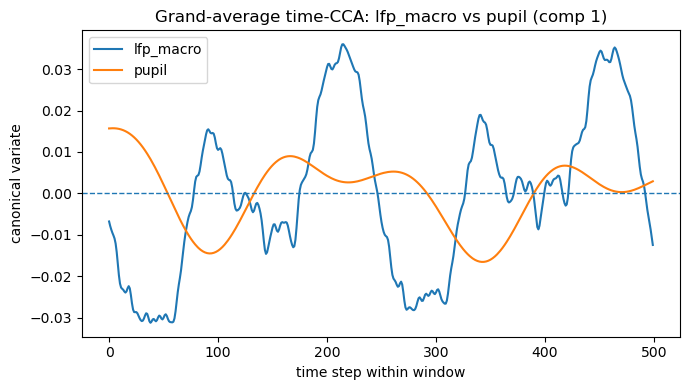

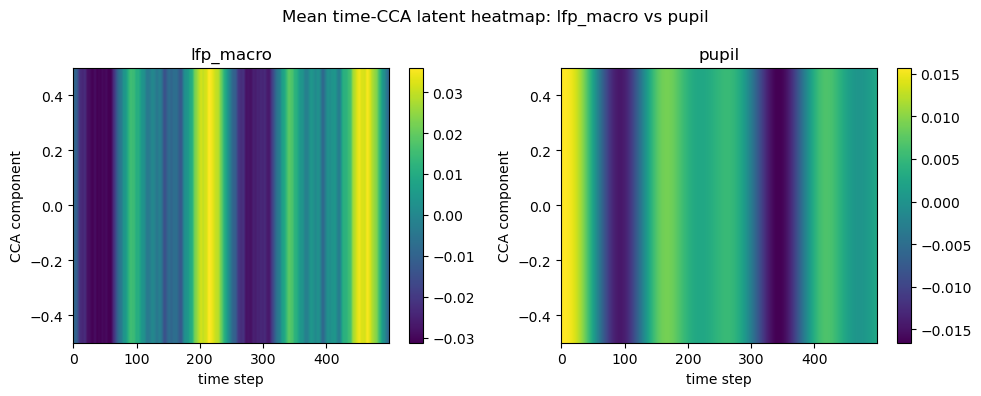

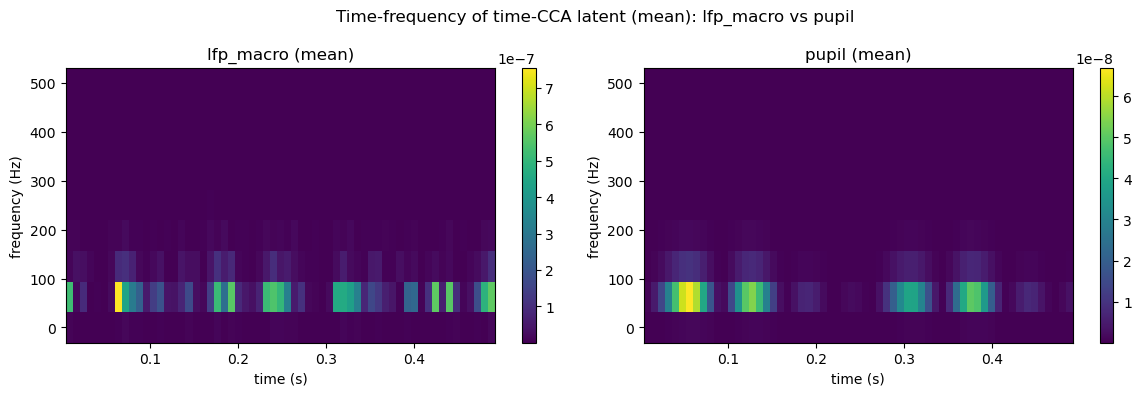

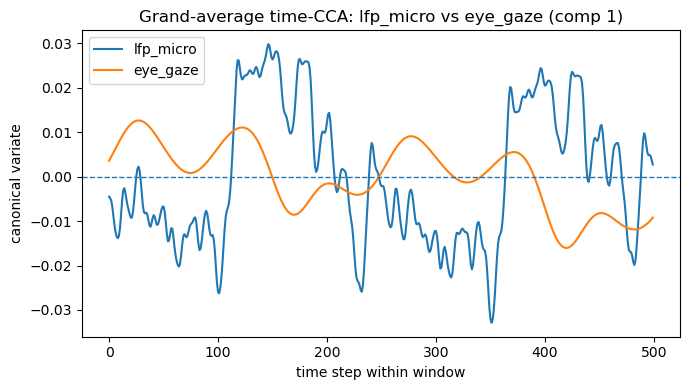

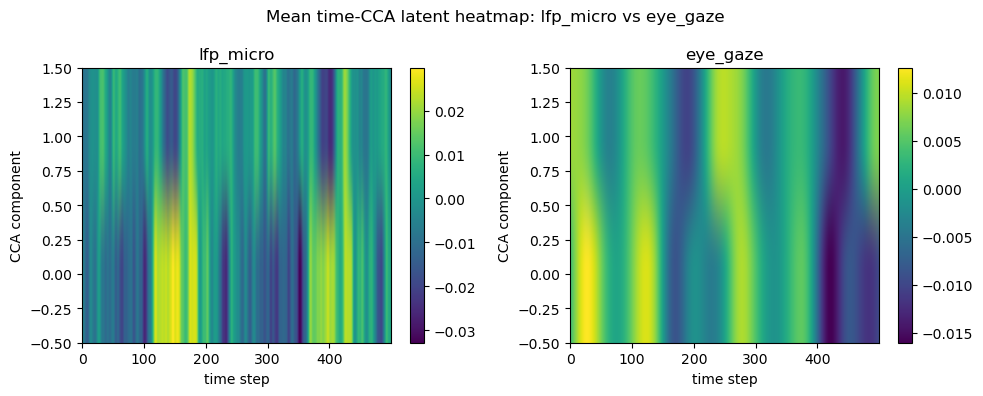

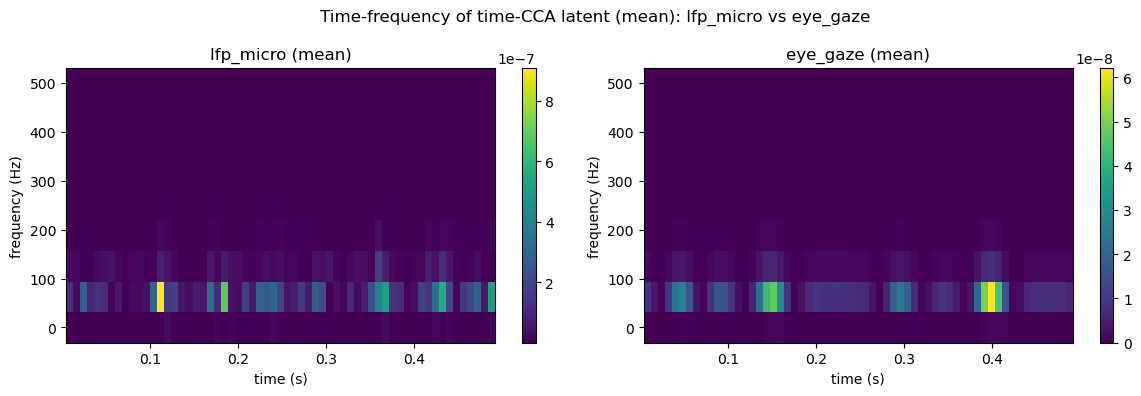

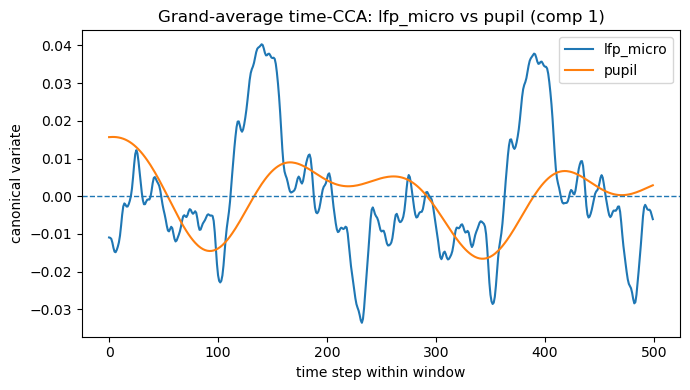

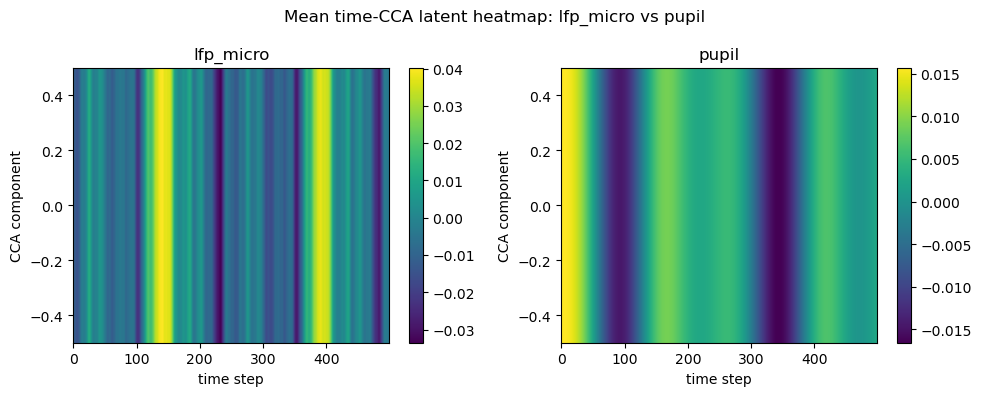

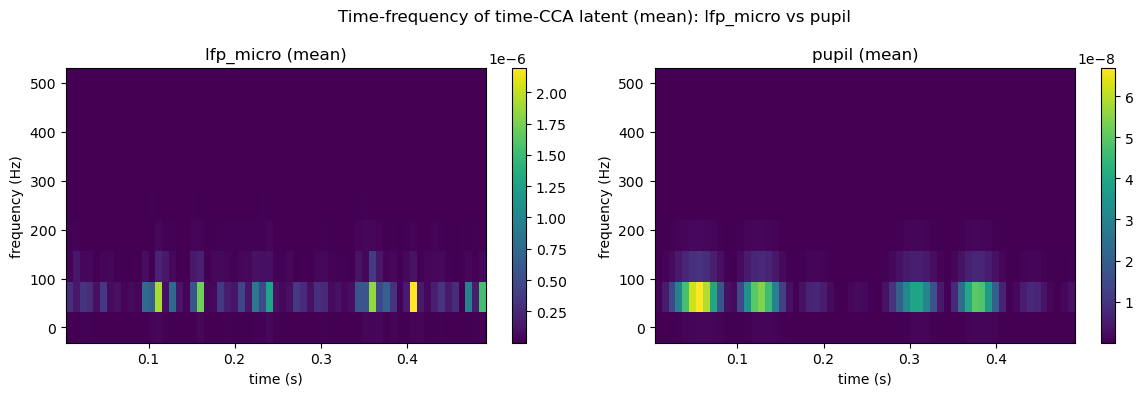

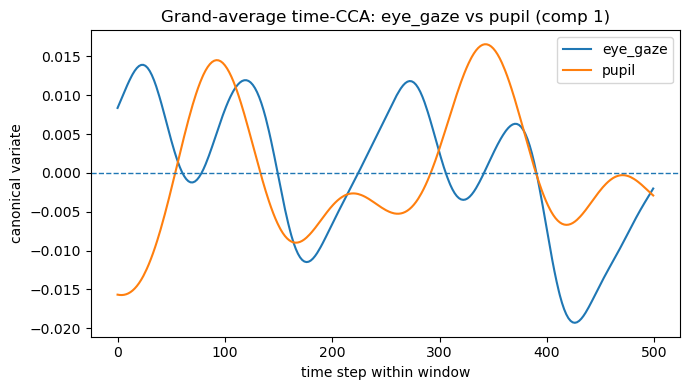

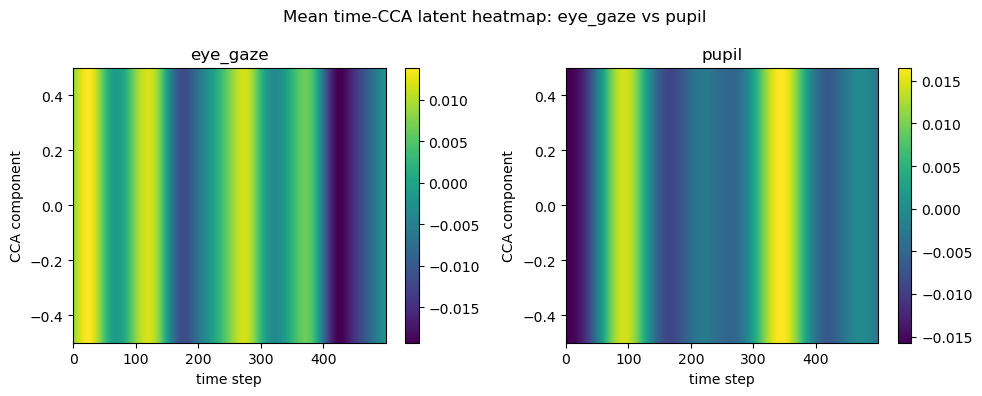

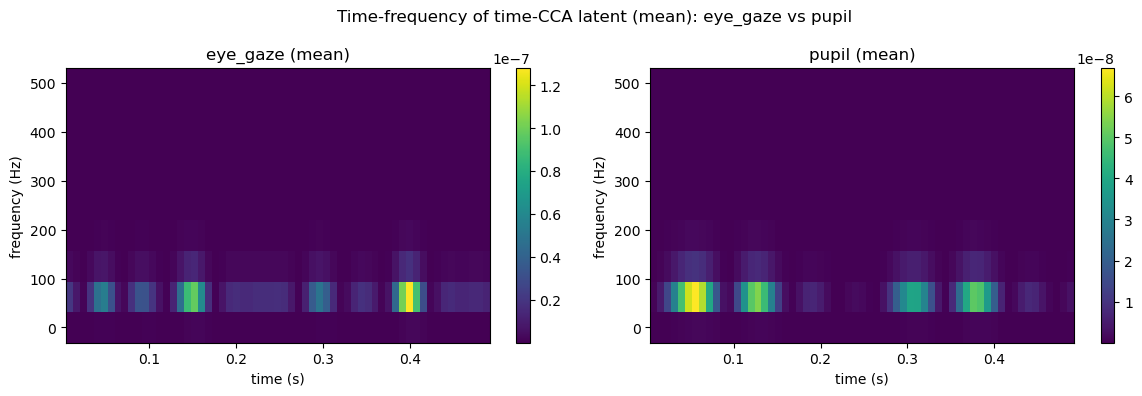

In [27]:
from itertools import combinations

for m1, m2 in combinations(modality_keys, 2):
    new_fusion.plot_time_cca_grandavg_timeseries(
        time_cca_res,
        m1,
        m2,
        comp=0,
        with_sem=True,
    )

    new_fusion.plot_time_cca_mean_timeseries_heatmap(
        time_cca_res,
        m1,
        m2,
    )

    new_fusion.plot_time_cca_latent_spectrogram(
        time_cca_res,
        m1,
        m2,
        feature_mode="mean",
        which="both",
        fs=1000,
        nperseg=16,
        noverlap=8,
    )

In [28]:
strong_pairs = [
    ("lfp_macro", "lfp_micro"),
    ("lfp_micro", "eye_gaze"),
    ("lfp_macro", "eye_gaze"),
]

In [29]:
from numpy.linalg import lstsq, eig
from scipy.signal import detrend

def compute_jpca(X, dt):
    """
    X: [T, D]
    dt: scalar
    """
    X = np.asarray(X, dtype=np.float64)

    if X.ndim != 2:
        raise ValueError(f"X must be 2D, got shape={X.shape}")
    if X.shape[0] < 3:
        raise ValueError(f"Need at least 3 time points, got shape={X.shape}")
    if not np.isfinite(dt) or dt <= 0:
        raise ValueError(f"dt must be positive finite, got dt={dt}")

    # 对齐成:
    # X_prev[t] 对应 dX[t] = (X[t+1]-X[t]) / dt
    X_prev = X[:-1]                    # [T-1, D]
    dX = np.diff(X, axis=0) / dt       # [T-1, D]

    # fit: dX = X_prev @ M
    M, _, _, _ = lstsq(X_prev, dX, rcond=None)   # M shape [D, D]

    # 旋转部分
    M_skew = 0.5 * (M - M.T)

    eigvals, eigvecs = eig(M_skew)
    return M, M_skew, eigvals, eigvecs

def project_to_jpca_plane(X, eigvecs, eigvals):
    """
    取虚部最大的那一对特征向量，构造2D jPCA plane
    """
    imag_strength = np.abs(np.imag(eigvals))
    idx = np.argsort(imag_strength)[-2:]

    W = np.real(eigvecs[:, idx])   # [D, 2]
    X_jpca = X @ W                 # [T, 2]
    return X_jpca, W, idx


def plot_jpca_trajectory(X_jpca, modality):
    plt.figure(figsize=(5, 5))
    plt.plot(X_jpca[:, 0], X_jpca[:, 1], linewidth=1)
    plt.scatter(X_jpca[0, 0], X_jpca[0, 1], label="start")
    plt.scatter(X_jpca[-1, 0], X_jpca[-1, 1], label="end")
    plt.xlabel("jPC1")
    plt.ylabel("jPC2")
    plt.title(f"{modality} jPCA plane")
    plt.legend()
    plt.axis("equal")
    plt.show()


def run_jpca_on_result(res, n_input_pc=6):
    X = np.asarray(res["pca_scores"], dtype=np.float64)
    X = detrend(X, axis=0)
    t = np.asarray(res["time"], dtype=np.float64)

    if X.ndim != 2:
        raise ValueError(f"pca_scores must be 2D, got {X.shape}")
    if len(t) != X.shape[0]:
        raise ValueError(f"time length {len(t)} != X rows {X.shape[0]}")
    if len(t) < 3:
        raise ValueError(f"Need at least 3 time points, got {len(t)}")

    # 去掉非有限时间差
    dt_all = np.diff(t)
    dt_all = dt_all[np.isfinite(dt_all) & (dt_all > 0)]
    if len(dt_all) == 0:
        raise ValueError("No valid positive dt found in time axis")
    dt = np.median(dt_all)

    # 限制输入维数
    k = min(n_input_pc, X.shape[1])
    X = X[:, :k]

    # 去掉含nan的行
    good = np.isfinite(X).all(axis=1) & np.isfinite(t)
    X = X[good]
    t = t[good]

    if X.shape[0] < 3:
        raise ValueError(f"Not enough valid rows after cleaning: {X.shape}")

    M, M_skew, eigvals, eigvecs = compute_jpca(X, dt)
    X_jpca, W, idx = project_to_jpca_plane(X, eigvecs, eigvals)

    plot_jpca_trajectory(X_jpca, res["modality"])

    print(f"{res['modality']} | input_dim={k}, T={X.shape[0]}, dt={dt:.6f}")
    print("eigenvalues:", eigvals)
    print("imag parts:", np.imag(eigvals))

    return {
        "X_jpca": X_jpca,
        "eigvals": eigvals,
        "eigvecs": eigvecs,
        "W": W,
        "idx": idx,
        "M": M,
        "M_skew": M_skew,
        "dt": dt,
    }

In [30]:
jpca_results = {}

for modality, res in results.items():
    if res is None:
        continue

    print("\n====", modality, "====")
    try:
        jpca_results[modality] = run_jpca_on_result(res, n_input_pc=6)
    except Exception as e:
        print(f"[skip] {modality}: {e}")

NameError: name 'results' is not defined